## AI 모델 개발 15회차 1차 팀프로젝트 - NASA Turbofan Jet Engine Data Set 터보엔진 유지보전 문제_FD002

[데이터셋 개요]
이 데이터셋은 NASA의 C-MAPSS(Commercial Modular Aero-Propulsion System Simulation)
시뮬레이터를 사용하여 생성된 터보팬 엔진의 열화(Degradation) 데이터입니다.

데이터는 여러 개의 다변량 시계열(Multivariate Time Series)로 구성되어 있습니다.
데이터셋은 학습(Training) 세트와 테스트(Test) 세트로 나뉩니다.
각 시계열 데이터는 서로 다른 엔진(Unit)에서 얻은 데이터이며, 동일한 유형의 엔진들로 간주할 수 있습니다.

[실험 시나리오]
1. 초기 상태: 각 엔진은 정상 상태에서 작동을 시작합니다.
   - 단, 사용자에게는 알려지지 않은 수준의 초기 마모(Initial Wear)와 제조 공차(Variation)가 존재합니다.
     (이는 결함이 아닌 정상적인 범주입니다.)
2. 고장 진행: 어느 시점부터 결함(Fault)이 발생하여 시간이 지날수록 상태가 악화됩니다.
3. 데이터 범위:
   - 학습 세트 (Train): 결함 발생부터 시스템 고장(Failure) 시점까지의 모든 데이터가 포함됩니다.
   - 테스트 세트 (Test): 고장 발생 전 임의의 시점에서 데이터 기록이 중단됩니다.

[목표 (Objective)]
테스트 세트에 포함된 각 엔진의 **잔여 유효 수명(RUL: Remaining Useful Life)**을 예측하는 것입니다.
즉, 테스트 데이터가 끊긴 시점으로부터 엔진이 고장 날 때까지 몇 사이클(Cycle)이 더 남았는지 맞히는 것이 목표입니다.

> FD002 (Train: train_FD002.txt / Test: test_FD002.txt / RUL: RUL_FD002.txt)
   - 학습 엔진 수: 260개
   - 테스트 엔진 수: 259개
   - 운전 조건 (Conditions): 6가지 (다양한 고도, 속도, 부하 조건)
   - 고장 모드 (Fault Modes): 1가지 (HPC 열화)


> 여러 셀에서 사용되는 함수는 먼저 정의하고 시작한다. 코드 오류 방지

Step 1. KMeans 폐기 $\to$ "Hard Clustering" (필수 적용)    
Step 2. "조건별 정규화" 후 "평활화 금지" (핵심)    
Step 3. 모델 입력 데이터의 "차원" 바꾸기 (Feature Engineering)    

## 1. 라이브러리 및 데이터 로드

In [ ]:
# 기본 라이브러리
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import math
warnings.filterwarnings('ignore')

## 2. 데이터 불러오기

In [ ]:
# kaggle에서 데이터 가져오기

%pip install kaggle==1.8.0

from dotenv import load_dotenv
load_dotenv()

!kaggle datasets download behrad3d/nasa-cmaps

In [ ]:
# 데이터 가져오기
import os
HOME = os.getcwd()
zipPath = os.path.join(HOME, "nasa-cmaps.zip")
targetPath = os.path.join(HOME, 'data')

from zipfile import ZipFile

with ZipFile(zipPath, 'r') as zip_ref:
    zip_ref.extractall(targetPath)


In [ ]:
parent_path = "C:/Users/user/github/EST_15th_NASA/한지형/data/CMaps"

#FD_ID = "FD001" # Conditions: ONE (Sea Level), Fault Modes: ONE (HPC Degradation)
FD_ID = "FD002" # Conditions: SIX, Fault Modes: ONE (HPC Degradation)
#FD_ID = "FD003" # Conditions: ONE (Sea Level), Fault Modes: TWO (HPC Degradation, Fan Degradation)
#FD_ID = "FD004" # Conditions: SIX , Fault Modes: TWO (HPC Degradation, Fan Degradation)

train_path = os.path.join(parent_path, f"train_{FD_ID}.txt")
test_path  = os.path.join(parent_path, f"test_{FD_ID}.txt")
rul_path   = os.path.join(parent_path, f"RUL_{FD_ID}.txt")

print(f"Train path: {train_path}")

col_names = [
    "unit_number", "time_in_cycles",
    "op_setting_1", "op_setting_2", "op_setting_3"
] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv(train_path, sep=r"\s+", header=None, names=col_names)
test_df = pd.read_csv(test_path, sep=r"\s+", header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep=r"\s+", header=None, names=["RUL"])


In [ ]:
train_df.head()

## 3. Feature Engineering

In [ ]:
rename_dict = {
    "op_setting_1": "Alt[kft]", # Altitude
    "op_setting_2": "Mn[-]", # Mach number
    "op_setting_3": "TLA[deg]", # Thrust lever angle (detent?)
    "sensor_1": "T2[R]",  # Total temperature at fan inlet 
    "sensor_2": "T24[R]", # Total temperature at LPC outlet
    "sensor_3": "T30[R]", # Total temperature at HPC outlet
    "sensor_4": "T50[R]", # Total temperature at LPT outlet
    "sensor_5": "P2[psi]", # Pressure at fan inlet
    "sensor_6": "P15[psi]", # Total pressure in bypass-duct
    "sensor_7": "P30[psi]", # Total pressure at HPC outlet
    "sensor_8": "Nf[rpm]", # Physical fan speed
    "sensor_9": "Nc[rpm]", # Physical core speed
    "sensor_10": "epr[-]", # Engine pressure ratio (P50/P2)
    "sensor_11": "phi[pph/psi]", # Ratio of fuel flow to Ps30, (not pps/psi, but pph/psi)
    "sensor_12": "Ps30[psi]", # Static pressure at HPC outlet
    "sensor_13": "NRf[rpm]", # Corrected fan speed
    "sensor_14": "NRc[rpm]", # Corrected core speed
    "sensor_15": "BPR[-]", # Bypass Ratio
    "sensor_16": "farB[-]", # Burner fuel-air ratio
    "sensor_17": "htBleed[]",# Bleed Enthalpy
    "sensor_18": "Nf_dmd[rpm]", # Demanded fan speed
    "sensor_19": "PCNfR_dmd[Pct]", # Demanded corrected fan speed
    "sensor_20": "W31[lbm/s]", # HPT coolant bleed
    "sensor_21": "W32[lbm/s]", # LPT coolant bleed
}


train_df = train_df.rename(columns=rename_dict)
test_df  = test_df.rename(columns=rename_dict)

def clean_round(series, ndigits=1, eps=1e-6):
    """Round values and force -0.0 to 0.0"""
    rounded = series.round(ndigits)
    rounded[rounded.abs() < eps] = 0
    return rounded

train_df['condition'] = (
    clean_round(train_df["Alt[kft]"], 0).astype(str) + '_' +
    clean_round(train_df["Mn[-]"], 1).astype(str) + '_' +
    clean_round(train_df["TLA[deg]"], 0).astype(str)
)

train_df.head()

In [ ]:
train_df["P50[psi]"] = train_df["epr[-]"]*train_df["P2[psi]"]

train_df["Fan.PR[-]"] = train_df["P15[psi]"]/train_df["P2[psi]"]
train_df["LPC.TR[-]"] = train_df["T24[R]"]/train_df["T2[R]"] # Fan core + LPC
train_df["HPC.TR[-]"] = train_df["T30[R]"]/train_df["T24[R]"]

train_df["OPR[-]"] = train_df["P30[psi]"]/train_df["P2[psi]"]

train_df["Wf[pph]"] = train_df["phi[pph/psi]"]*train_df["Ps30[psi]"]
train_df["Wa36[lbm/s]"] = train_df["Wf[pph]"]/3600.0 / train_df["farB[-]"]
train_df["W24[lbm/s]"] = train_df["Wa36[lbm/s]"] + train_df["W31[lbm/s]"] + train_df["W32[lbm/s]"] # core. htBleed ? 
train_df["W15[lbm/s]"] = train_df["W24[lbm/s]"]*train_df["BPR[-]"] # bypass
train_df["W2[lbm/s]"] = train_df["W15[lbm/s]"] + train_df["W24[lbm/s]"] # overall

train_df["WfP3C[pph/psi]"] = train_df["phi[pph/psi]"]/np.sqrt(train_df["T2[R]"]/518.67)

train_df.head()


### 컬럼 설명 (Data Dictionary)

| 컬럼명 | 설명 | 타입 |
|---|---|---|
| **unit_number** | 엔진 고유 식별자 (Unit Number) | int64 |
| **time_in_cycles** | 운전 사이클 (Time in Cycles) | int64 |
| **Alt[kft]** | 고도 (Altitude) | float64 |
| **Mn[-]** | 마하 수 (Mach Number) | float64 |
| **TLA[deg]** | 스로틀 레버 각도 (Thrust Lever Angle) | float64 |
| **T2[R]** | 팬 입구 전온도 (Total temperature at fan inlet) | float64 |
| **T24[R]** | LPC 출구 전온도 (Total temperature at LPC outlet) | float64 |
| **T30[R]** | HPC 출구 전온도 (Total temperature at HPC outlet) | float64 |
| **T50[R]** | LPT 출구 전온도 (Total temperature at LPT outlet) | float64 |
| **P2[psi]** | 팬 입구 압력 (Pressure at fan inlet) | float64 |
| **P15[psi]** | 바이패스 덕트 전압력 (Total pressure in bypass-duct) | float64 |
| **P30[psi]** | HPC 출구 전압력 (Total pressure at HPC outlet) | float64 |
| **Nf[rpm]** | 물리적 팬 속도 (Physical fan speed) | float64 |
| **Nc[rpm]** | 물리적 코어 속도 (Physical core speed) | float64 |
| **epr[-]** | 엔진 압력비 (Engine pressure ratio) | float64 |
| **phi[pph/psi]** | 연료 유량 대 Ps30 비율 (Ratio of fuel flow to Ps30) | float64 |
| **Ps30[psi]** | HPC 출구 정압 (Static pressure at HPC outlet) | float64 |
| **NRf[rpm]** | 보정된 팬 속도 (Corrected fan speed) | float64 |
| **NRc[rpm]** | 보정된 코어 속도 (Corrected core speed) | float64 |
| **BPR[-]** | 바이패스 비 (Bypass Ratio) | float64 |
| **farB[-]** | 연소기 연료-공기 비 (Burner fuel-air ratio) | float64 |
| **htBleed[]** | 블리드 엔탈피 (Bleed Enthalpy) | int64 |
| **Nf_dmd[rpm]** | 요구 팬 속도 (Demanded fan speed) | int64 |
| **PCNfR_dmd[Pct]** | 요구 보정 팬 속도 (Demanded corrected fan speed) | float64 |
| **W31[lbm/s]** | HPT 냉각 블리드 (HPT coolant bleed) | float64 |
| **W32[lbm/s]** | LPT 냉각 블리드 (LPT coolant bleed) | float64 |
| **condition** | 운전 조건 문자열 (Operational Condition String) | object |
| **P50[psi]** | LPT 출구 전압력 (Total pressure at LPT outlet) | float64 |
| **Fan.PR[-]** | 팬 압력비 (Fan pressure ratio) | float64 |
| **LPC.TR[-]** | LPC 전온도비 (LPC total temperature ratio) | float64 |
| **HPC.TR[-]** | HPC 전온도비 (HPC total temperature ratio) | float64 |
| **OPR[-]** | 전체 압력비 (Overall pressure ratio) | float64 |
| **Wf[pph]** | 연료 유량 (Fuel flow) | float64 |
| **Wa36[lbm/s]** | 코어 공기 유량 (Core airflow) | float64 |
| **W24[lbm/s]** | LPC 공기 유량 (LPC airflow) | float64 |
| **W15[lbm/s]** | 바이패스 공기 유량 (Bypass airflow) | float64 |
| **W2[lbm/s]** | 팬 유입 공기 유량 (Fan inlet airflow) | float64 |
| **WfP3C[pph/psi]** | P3 압력 대비 연료 유량 (Fuel flow to P3 pressure ratio) | float64 |
| **RUL** | 엔진의 남은 수명 (Remaining Useful Life) | int64 |

In [ ]:
train_df.info()

In [ ]:
pd.set_option('display.max_rows', None)
summary_df = pd.DataFrame(train_df.dtypes, columns=['Data Type'])
summary_df = summary_df.reset_index()
summary_df = summary_df.rename(columns={'index': 'Column Name'})
summary_df['Non-Null Count'] = train_df.count().values
summary_df['Null Count'] = train_df.isnull().sum().values
summary_df['Null Ratio (%)'] = (train_df.isnull().sum().values / len(train_df)) * 100
summary_df


### 정규화 / 이상치 처리
* FD002는 FD001과 다르게 운전 조건이 단일 조건이 아니기 때문에 고도와 속도가 변한다.
1. 따라서 데이터를 여러 그룹(클러스터)로 나눠 (고도(Altitude), 마하수(Mach Number), 스로틀(TRA) 조합에 따라 총 6가지 운전 모드로 클러스터링) 
2. 클러스터링 과정에서 생성되는 cluster 컬럼을 one-hot encoding으로 클러스터 분간용도로 변환.
3. 그룹별로 정규화를 하고 (Z-score) (고도나 속도 마다 온도 등 센서 수치가 다르기 때문에 이 차이를 없애기 위해 정규화) (trand 분리화) + Mode_ID를 포함한 조건부 정규화를 추가한다.
4. z-score가 ±3을 벗어나는 이상치를 clipping 한다.
5. 정규화된 데이터를 다시 합쳐 모델에 넣는다.

* 기존에 운전조건으로만 6구간을 나눠 정규화한 데이터를 사용한 결과 아래 그림과 같이 산점도에서 farB[-]의 이봉 분포(두 줄로 갈라지는 현상)에 의해 farB[-]에서 파생된 W15, W24, W2, Wa36 에도 cluster 1 데이터가 직선형으로 혼재
* 이 문제를 해결하기 위해 one-hot encoding + farB의 cluster1 데이터를 이봉 분포 기준에 따라 mode_ID (0,1)로 condition_id하는 기준을 추가한다.
* 노이즈 제거는 과정에서 컬럼이 매우 많이 파생되므로 EDA, feature selection 이후에 진행한다.

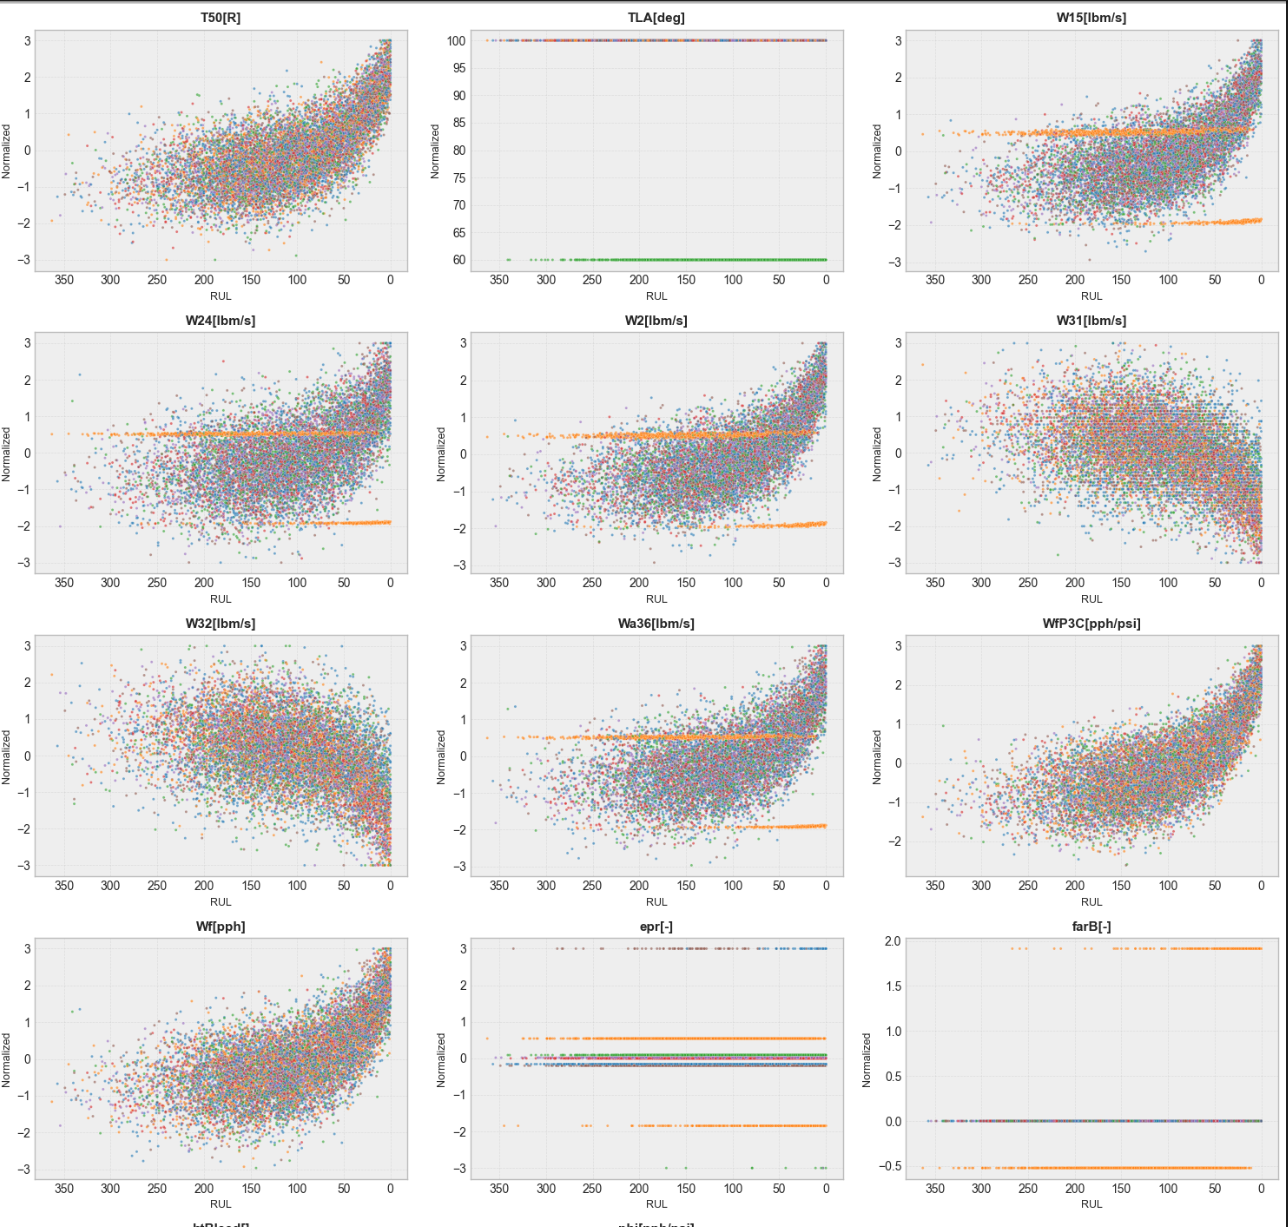

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

def apply_advanced_feature_engineering(df):
    """
    1. 기본 Clustering (6개)
    2. Cluster One-Hot Encoding (모델 학습용)
    3. Mode_ID 생성 (Cluster 1 내부 이봉 분포 분리)
    4. Condition_ID (Cluster + Mode) 기준 정규화 및 이상치 처리
    """
    df_norm = df.copy()
    
    # ---------------------------------------------------------
    # 1. 클러스터링 (운전 조건 그룹화)
    # ---------------------------------------------------------
    # 고도, 마하수, 스로틀 기준으로 운전 조건(Condition) 나누기
    print("🚀 [1] 클러스터링(K-Means) 진행 중...")
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    df_norm['cluster'] = kmeans.fit_predict(df_norm[['Alt[kft]', 'Mn[-]', 'TLA[deg]']])
    
    # ---------------------------------------------------------
    # 2. (A) Cluster One-Hot Encoding 추가
    # ---------------------------------------------------------
    # 모델이 조건별 규칙을 학습할 수 있도록 명시적 피처 추가
    cluster_oh = pd.get_dummies(df_norm['cluster'], prefix='cluster', dtype=int)
    df_norm = pd.concat([df_norm, cluster_oh], axis=1)
    print("✅ Cluster One-Hot Encoding 완료")

    # ---------------------------------------------------------
    # 3. (B) Mode_ID 생성 (Cluster 1 내부 세분화)
    # ---------------------------------------------------------
    # farB 센서값이 Cluster 1에서 두 갈래로 나뉘는 현상 해결
    print("🚀 [2] Mode_ID 생성 (Cluster 1 세분화) 진행 중...")
    
    df_norm['Mode_ID'] = 0 # 기본값 0
    
    # Cluster 1 데이터만 추출
    mask_c1 = (df_norm['cluster'] == 1)
    farb_c1 = df_norm.loc[mask_c1, ['farB[-]']].values
    
    if len(farb_c1) > 10:
        # farB 기준으로 2개로 다시 나눔
        km_mode = KMeans(n_clusters=2, random_state=42, n_init=10)
        mode_labels = km_mode.fit_predict(farb_c1)
        
        # 값이 큰 쪽을 Mode 1로 통일 (일관성 유지)
        centers = km_mode.cluster_centers_.reshape(-1)
        if centers[1] < centers[0]:
            mode_labels = 1 - mode_labels
            
        df_norm.loc[mask_c1, 'Mode_ID'] = mode_labels
        print(f"   - Cluster 1 내부 분리 완료 (Centers: {centers})")
    else:
        print("   - 경고: Cluster 1 데이터 부족으로 분리 생략")
        
    # Condition ID 생성 (Cluster와 Mode를 합친 새로운 기준)
    # 예: Cluster 1, Mode 1 -> 11, Cluster 2, Mode 0 -> 20
    df_norm['condition_id'] = df_norm['cluster'] * 10 + df_norm['Mode_ID']

    # ---------------------------------------------------------
    # 4. (C) 정규화 (Condition-based Z-Score) & 이상치 처리
    # ---------------------------------------------------------
    print("🚀 [3] Condition_ID 기준 정규화 및 이상치 처리 진행 중...")
    
    # 정규화 대상 컬럼 선정 (센서값만, 설정값/One-Hot 등 제외)
    sensor_cols = [c for c in df_norm.columns if 'sensor' in c or '[' in c]
    exclude = ['unit_number', 'time_in_cycles', 'RUL', 'cluster', 'Mode_ID', 'condition_id', 
               'Alt[kft]', 'Mn[-]', 'TLA[deg]', 'max_cycle']
    # One-Hot 컬럼도 제외
    target_sensors = [c for c in sensor_cols if c not in exclude and not c.startswith('cluster_')]

    print(f"   - 정규화 대상 센서: {len(target_sensors)}개")

    for col in target_sensors:
        # condition_id 별로 그룹지어 정규화 수행
        # 이렇게 하면 Cluster 1 내부의 두 갈래 데이터가 각각의 평균 중심으로 모이게 됨
        df_norm[col] = df_norm.groupby('condition_id')[col].transform(
            lambda x: (x - x.mean()) / (x.std() + 1e-6)
        )
        
        # 이상치 처리 (Clipping)
        df_norm[col] = df_norm[col].clip(-3, 3)
        
    print("✅ 모든 전처리 과정 완료!")
    
    return df_norm

# 실행
train_norm = apply_advanced_feature_engineering(train_df)
print(f"결과 데이터셋: train_norm (컬럼 수: {train_norm.shape[1]})")
# 확인용 출력
print(train_norm[['cluster', 'Mode_ID', 'condition_id']].value_counts().sort_index().head(10))

In [ ]:
# 1. 각 클러스터별 설정(Setting) 값의 평균 확인
# (train_norm에는 cluster 컬럼과 원본 설정값이 모두 들어있습니다)
cluster_profile = train_norm.groupby('cluster')[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].mean()
cluster_count = train_norm['cluster'].value_counts()

# 2. 보기 좋게 정렬 및 병합 (개수 포함)
cluster_profile['count'] = cluster_count

# 고도(Alt) 순서대로 정렬해서 출력 (물리적 의미 파악 용이)
print("📊 Cluster Profile (Operating Conditions):")
print(cluster_profile.sort_values('Alt[kft]'))

* 클러스터링 시각화

In [ ]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---------------------------------------------------------
# 1. 실제 데이터에서 Centroid 자동 계산
# ---------------------------------------------------------
# 하드코딩 대신 train_norm에서 직접 계산합니다.
# (이래야 Step 3 결과와 100% 일치합니다)

if 'train_norm' in globals():
    # 클러스터별 평균 계산
    cluster_stats = train_norm.groupby('cluster')[['Alt[kft]', 'Mn[-]', 'TLA[deg]']].mean()
    
    # 고도(Alt) 순서대로 정렬 (낮은 고도 -> 높은 고도)
    df_centroids = cluster_stats.sort_values('Alt[kft]').reset_index()
    
    # 설명(Description) 라벨 자동 할당 (고도 순서 기반)
    descriptions = [
        "Sea Level (Ground)", 
        "Low Alt 1", 
        "Low Alt 2", 
        "Mid Alt (Cruise)", 
        "High Alt 1", 
        "High Alt 2"
    ]
    # 만약 클러스터 개수가 안 맞으면 안전하게 처리
    if len(df_centroids) == len(descriptions):
        df_centroids['Desc'] = descriptions
    else:
        df_centroids['Desc'] = [f"Zone {i}" for i in range(len(df_centroids))]
        
    # 컬럼명 통일 (시각화 코드 호환용)
    df_centroids = df_centroids.rename(columns={'cluster': 'Cluster', 
                                                'Alt[kft]': 'Alt', 
                                                'Mn[-]': 'Mn', 
                                                'TLA[deg]': 'TLA'})
else:
    print("⚠️ train_norm 데이터가 없습니다. Step 3를 먼저 실행해주세요.")
    # 비상용 더미 데이터 (에러 방지)
    df_centroids = pd.DataFrame(columns=['Cluster', 'Alt', 'Mn', 'TLA', 'Desc'])

# ---------------------------------------------------------
# 2. 경계벽(Wall) 위치 계산
# ---------------------------------------------------------
alts = df_centroids['Alt'].values
wall_positions = [(alts[i] + alts[i+1])/2 for i in range(len(alts)-1)]
boundaries = [-5] + list(wall_positions) + [45]

# Y축(Mn), Z축(TLA) 범위
y_min, y_max = -0.1, 1.0
z_min, z_max = 0, 110

# ---------------------------------------------------------
# 3. 3D 공간 분할 시각화
# ---------------------------------------------------------
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

# (1) 경계벽(Wall) 그리기
colors = plt.cm.viridis(np.linspace(0, 1, len(df_centroids)))

for i, x_pos in enumerate(wall_positions):
    verts = [
        [(x_pos, y_min, z_min), (x_pos, y_max, z_min), 
         (x_pos, y_max, z_max), (x_pos, y_min, z_max)]
    ]
    wall = Poly3DCollection(verts, alpha=0.15, facecolor='deepskyblue', edgecolor='royalblue', linewidth=0.5)
    ax.add_collection3d(wall)
    ax.text(x_pos, y_max, z_max + 5, f"Alt={x_pos:.1f}", color='blue', fontsize=9, ha='center')

# (2) 중심점(Centroid) 및 영역 표시
for i, row in df_centroids.iterrows():
    # 중심점
    ax.scatter(row['Alt'], row['Mn'], row['TLA'], 
               color=colors[i], s=200, edgecolor='k', alpha=1.0, label=f"Cluster {int(row['Cluster'])}")
    
    # 텍스트 라벨 (Condition ID 정보도 추가하면 좋음)
    label_text = f"Cluster {int(row['Cluster'])}\n({row['Desc']})"
    
    # 만약 이 클러스터가 Mode가 나뉘는 곳(Cluster 1 추정)이라면 표시
    if 'Mode_ID' in train_norm.columns:
        # 해당 클러스터에 Mode가 2개 이상인지 확인
        n_modes = train_norm[train_norm['cluster'] == row['Cluster']]['Mode_ID'].nunique()
        if n_modes > 1:
            label_text += "\n(Multi-Mode)"
            
    ax.text(row['Alt'], row['Mn'], row['TLA'] + 5, 
            label_text, color='black', fontsize=10, fontweight='bold', ha='center')
    
    # 바닥 투영선
    ax.plot([row['Alt'], row['Alt']], [row['Mn'], row['Mn']], [0, row['TLA']], 
            color=colors[i], linestyle='--', alpha=0.5)

# ---------------------------------------------------------
# 4. 그래프 꾸미기
# ---------------------------------------------------------
ax.set_xlabel('Altitude [kft]', fontsize=12, labelpad=10)
ax.set_ylabel('Mach Number [-]', fontsize=12, labelpad=10)
ax.set_zlabel('Throttle [deg]', fontsize=12, labelpad=10)
ax.set_title("6 Operating Zones (Auto-Detected)", fontsize=16, fontweight='bold', pad=20)

ax.set_xlim(-5, 50)
ax.set_ylim(y_min, y_max)
ax.set_zlim(0, 120)
ax.view_init(elev=20, azim=-70)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. 구간 정의표 출력
# ---------------------------------------------------------
print("\n [Operating Zones & Boundaries Table]")
print("=" * 75)
print(f"{'Zone':<6} | {'Cluster':<8} | {'Altitude Range [kft]':<25} | {'Description'}")
print("-" * 75)

for i in range(len(boundaries)-1):
    low = boundaries[i]
    high = boundaries[i+1]
    cluster_id = df_centroids.iloc[i]['Cluster']
    desc = df_centroids.iloc[i]['Desc']
    
    range_str = f"{low:.1f} < Alt < {high:.1f}"
    if i == 0: range_str = f"Alt < {high:.1f} (Ground)"
    if i == len(boundaries)-2: range_str = f"Alt > {low:.1f} (High Alt)"
    
    print(f" {i+1:<5} | {int(cluster_id):<8} | {range_str:<25} | {desc}")
print("=" * 75)

In [ ]:
def add_rul(df):
    """각 엔진별 RUL(잔여 수명) 계산"""
    max_cycles = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.merge(max_cycles.to_frame(name='max_cycle'), 
                  left_on='unit_number', right_index=True)
    df['RUL'] = df['max_cycle'] - df['time_in_cycles']
    df.drop('max_cycle', axis=1, inplace=True)
    return df
# train_df에 RUL 추가
train_df = add_rul(train_df)
print(f"✅ RUL 컬럼 추가 완료!")
print(train_df[['unit_number', 'time_in_cycles', 'RUL']].head(10))

* 작업 전후 비교 전에 추세가 확실한 컬럼 3개 찾기

In [ ]:
# RUL 컬럼이 없다면 이식
if 'RUL' not in train_norm.columns:
    train_norm['RUL'] = train_df['RUL']

print(f"✅ train_norm 데이터 준비 완료! (컬럼 수: {train_norm.shape[1]})")

# ---------------------------------------------------------
# 1. 어떤 센서가 RUL과 가장 관련이 깊을까? (상관관계 분석)
# ---------------------------------------------------------
# 분석 대상: 정규화된 'train_norm'
# 클러스터링 관련 컬럼 제외하고 순수 센서만 선택
features = [c for c in train_norm.columns if ('sensor' in c or '[' in c) 
            and c not in ['RUL', 'unit_number', 'time_in_cycles', 'cluster', 'Alt[kft]', 'Mn[-]', 'TLA[deg]']]

# 상관관계 계산
correlations = train_norm[features + ['RUL']].corr()['RUL'].drop('RUL')
top_features = correlations.abs().sort_values(ascending=False).head(3)

print("\n🏆 RUL과 가장 강력한 추세를 가진 Top 3 센서 (Normalized):")
print(top_features)

# ---------------------------------------------------------
# 2. Top 1 센서의 "진짜 추세" 시각화
# ---------------------------------------------------------
if len(top_features) > 0:
    best_sensor = top_features.index[0] # 1등 센서 이름

    # 데이터 샘플링 (속도 향상)
    sample_df = train_norm.sample(frac=0.1, random_state=42)

    plt.figure(figsize=(12, 6))
    
    # 산점도 그리기
    plt.scatter(sample_df['RUL'], sample_df[best_sensor], 
                alpha=0.1, s=10, c='red', label='Data Points')

    # 추세선 (Trend Line) 추가
    sns.regplot(data=sample_df, x='RUL', y=best_sensor, scatter=False, 
                color='black', line_kws={'linestyle':'--', 'linewidth':2})

    plt.gca().invert_xaxis() # X축 반전: 오른쪽(0)이 고장 시점
    plt.title(f"Best Trend Feature: {best_sensor} vs RUL (Normalized)", fontsize=15, fontweight='bold')
    plt.xlabel("Remaining Useful Life (RUL) -> Decreasing")
    plt.ylabel(f"Normalized Value (Z-Score of {best_sensor})")
    plt.axhline(0, color='blue', linestyle=':', alpha=0.5, label='Mean (0)') # 평균선
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("❌ 상관관계를 계산할 센서 컬럼을 찾지 못했습니다.")

* 정규화 / 이상치 처리 / 노이즈 제거 작업 전후 비교

In [ ]:

# 스타일 설정 (세련된 스타일 유지)
plt.style.use('bmh')

# ---------------------------------------------------------
# 1. [단일 엔진] 시계열 변화 비교 (Raw vs Normalized)
# ---------------------------------------------------------
def plot_trajectory_comparison_step5(unit_id, sensor_name):
    print(f"   ... Drawing Trajectory for {sensor_name}")
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 해당 유닛 데이터 추출
    unit_data_raw = train_df[train_df['unit_number'] == unit_id]
    
    # (1) Raw Data Plot
    if sensor_name in unit_data_raw.columns:
        axes[0].plot(unit_data_raw['time_in_cycles'], 
                     unit_data_raw[sensor_name], 
                     color='royalblue', linewidth=1.5, alpha=0.8)
        axes[0].set_title(f"1. Raw Data (Original)\nCondition Mixed", fontsize=11, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, "Column Not Found", ha='center')
        
    axes[0].set_ylabel("Sensor Value", fontsize=10)
    axes[0].set_xlabel("Cycles", fontsize=10)
    axes[0].grid(True, alpha=0.3)
    
    # (2) Normalized Data Plot (train_norm)
    if 'train_norm' in globals() and sensor_name in train_norm.columns:
        unit_data_norm = train_norm[train_norm['unit_number'] == unit_id]
        
        # Condition ID 기반 정규화 결과 확인
        axes[1].plot(unit_data_norm['time_in_cycles'], 
                     unit_data_norm[sensor_name], 
                     color='crimson', linewidth=1.5, alpha=0.8)
        
        axes[1].set_title(f"2. Normalized (Condition Removed)\nCenter Aligned", fontsize=11, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, "Not in train_norm", ha='center')

    axes[1].set_ylabel("Z-Score (Clipped)", fontsize=10)
    axes[1].set_xlabel("Cycles", fontsize=10)
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f"Preprocessing Effect: {sensor_name} (Unit {unit_id})", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# ---------------------------------------------------------
# 2. [전체 데이터] Global Trend 비교 (Scatter + Time Color)
# ---------------------------------------------------------
def plot_global_trend_step5(sensor_name):
    print(f"   ... Drawing Global Trend for {sensor_name}")

    # 데이터 샘플링 (10%)
    sample_raw = train_df.sample(frac=0.1, random_state=42)
    
    if 'train_norm' in globals():
        sample_norm = train_norm.loc[sample_raw.index]
    else:
        print("⚠️ train_norm 데이터가 없습니다.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # (1) Raw Data vs RUL
    if sensor_name in sample_raw.columns:
        sc1 = axes[0].scatter(sample_raw['RUL'], sample_raw[sensor_name], 
                              s=1, alpha=0.3, 
                              c=sample_raw['time_in_cycles'], cmap='plasma') # 시간 경과에 따른 색상
        plt.colorbar(sc1, ax=axes[0]).set_label("Cycles")
        axes[0].set_title(f"Raw Data vs RUL", fontsize=11, fontweight='bold')
    else:
        axes[0].text(0.5, 0.5, "Column Not Found")

    axes[0].set_xlabel("RUL", fontsize=10)
    axes[0].set_ylabel("Raw Value", fontsize=10)
    axes[0].invert_xaxis()
    axes[0].grid(True, alpha=0.3)
    
    # (2) Normalized Data vs RUL
    if sensor_name in sample_norm.columns:
        sc2 = axes[1].scatter(sample_raw['RUL'], sample_norm[sensor_name], 
                              s=1, alpha=0.3, 
                              c=sample_raw['time_in_cycles'], cmap='plasma')
        plt.colorbar(sc2, ax=axes[1]).set_label("Cycles")
        axes[1].set_title(f"Normalized Data vs RUL\n(Bias Removed)", fontsize=11, fontweight='bold')
    else:
        axes[1].text(0.5, 0.5, "Column Not Found")
        
    axes[1].set_xlabel("RUL", fontsize=10)
    axes[1].set_ylabel("Z-Score", fontsize=10)
    axes[1].invert_xaxis()
    axes[1].grid(True, alpha=0.3)
    
    plt.show()

# ---------------------------------------------------------
# 🔥 실행 (Step 5 시점)
# ---------------------------------------------------------
print("📊 [Step 5] 정규화 전후 비교 시각화 시작...")

# RUL 컬럼 이식
if 'train_norm' in globals() and 'RUL' not in train_norm.columns:
    train_norm['RUL'] = train_df['RUL']

# 🎯 [핵심] 검증할 센서 목록 선정
# 1. 우리가 아까 공들여 고친 'farB'나 'w24' 같은 녀석들을 꼭 확인해야 합니다.
# 2. 일반적인 주요 센서들도 포함합니다.

target_sensors = [
    'WfP3C[pph/psi]', # 연료 효율 (전통적 강자)
    'T50[R]',         # 온도 (전통적 강자)
    'farB[-]',        # ★ 아까 Cluster 1에서 갈라지던 녀석 (Mode_ID 효과 검증용)
    'Nf_dmd[%]',      # 회전수
    'PCNfR_dmd[%]'    # 회전수
]

# (혹시 컬럼명이 다르면 물리명 대신 sensor_xx 형태일 수 있으니 체크)
check_cols = [c for c in target_sensors if c in train_df.columns]
if not check_cols:
    # 만약 물리명이 없으면 sensor_번호 형태로 시도
    check_cols = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_8', 'sensor_11', 'sensor_13']
    check_cols = [c for c in check_cols if c in train_df.columns]

print(f"🎯 검증 대상 센서: {check_cols}")

for sensor in check_cols:
    plot_trajectory_comparison_step5(unit_id=2, sensor_name=sensor)

# 가장 중요한 센서 하나로 전체 트렌드 확인
if len(check_cols) > 0:
    print(f"\n🌍 Global Trend Check ({check_cols[0]})")
    plot_global_trend_step5(check_cols[0])
    
    # farB가 있다면 얘도 꼭 확인!
    farb_col = 'farB[-]' if 'farB[-]' in train_df.columns else 'sensor_?' 
    if farb_col in train_df.columns:
        print(f"\n🌍 Global Trend Check ({farb_col}) - ★ Mode_ID 효과 확인")
        plot_global_trend_step5(farb_col)

* 왼쪽 그래프의 6개 선은 6가지 운전 조건을 의미 (운전조건의 영향이 강해 고장에 의한 추세(Trend)가 안 보인다.)
* 선들이 사라지고 추세가 보인다.

### RUL Clipping

In [ ]:
from xgboost import XGBRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error
import numpy as np

# RUL 컬럼 생성 (이미 되어 있다면 생략 가능)
if 'RUL' not in train_norm.columns:
    max_cycle = train_norm.groupby('unit_number')['time_in_cycles'].transform('max')
    train_norm['RUL'] = max_cycle - train_norm['time_in_cycles']
    print("RUL 컬럼 생성 완료!")

# ---------------------------------------------------------
# NASA Score 기반 Grid Search
# ---------------------------------------------------------
print("🔎 NASA Score 기준으로 최적 RUL Clipping 탐색...")

def compute_nasa_score(y_true, y_pred):
    d = np.array(y_pred) - np.array(y_true)
    scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(scores)

candidate_limits = [100, 110, 115, 120, 125, 130, 140, 150]
best_nasa = float('inf')
best_limit = 125

# 수치형 컬럼만 선택
numeric_cols = train_norm.select_dtypes(include=[np.number]).columns
features = [c for c in numeric_cols if c not in ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 'Mode_ID']]
groups = train_norm['unit_number']

for limit in candidate_limits:
    # y값 Clipping
    y_candidate = train_norm['RUL'].clip(upper=limit)
    X_candidate = train_norm[features]
    
    # GroupShuffleSplit (Data Leakage 방지)
    gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
    train_idx, val_idx = next(gss.split(X_candidate, y_candidate, groups))
    
    X_tr, X_val = X_candidate.iloc[train_idx], X_candidate.iloc[val_idx]
    y_tr, y_val = y_candidate.iloc[train_idx], y_candidate.iloc[val_idx]
    
    # XGBoost 모델 정의
    model = XGBRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, 
                         random_state=42, n_jobs=-1, verbosity=0)
    
    # -----------------------------------------------------------
    # [수정된 부분] .values를 붙여서 Numpy Array로 변환하여 학습
    # -----------------------------------------------------------
    model.fit(X_tr.values, y_tr.values)
    pred = model.predict(X_val.values)
    
    rmse = np.sqrt(mean_squared_error(y_val, pred))
    nasa = compute_nasa_score(y_val.values, pred)
    
    print(f"   Limit: {limit:>4d} | RMSE: {rmse:.2f} | NASA Score: {nasa:,.0f}")
    
    if nasa < best_nasa:
        best_nasa = nasa
        best_limit = limit

print(f"\n🏆 NASA Score 기준 최적 Limit: {best_limit} (Score: {best_nasa:,.0f})")

# 최종 적용
train_norm['RUL'] = train_norm['RUL'].clip(upper=best_limit)
print(f"✅ RUL Clipping 완료! (최대값 {best_limit})")
print(train_norm['RUL'].describe())

In [ ]:
# numeric_only=True 옵션을 추가하여 문자열 컬럼을 자동으로 제외시킵니다.
current_corr = train_norm.corrwith(train_norm['RUL'], numeric_only=True).abs().sort_values(ascending=False)

print("📊 [팩트 체크] RUL Clipping 적용 후 현재 상관계수 TOP 10:")
print(current_corr.head(15))

print("\n------------------------------------")
# .get()을 사용하여 해당 컬럼이 없더라도 에러가 나지 않도록 처리
print(f"👉 Nc(Core Speed)의 현재 상관계수: {current_corr.get('Nc', current_corr.get('Nc[rpm]', '이미 삭제됨'))}")
print(f"👉 Nf(Fan Speed)의 현재 상관계수:  {current_corr.get('Nf', current_corr.get('Nf[rpm]', '이미 삭제됨'))}")

# EDA

## unit 별 최대 수명 분석

In [ ]:

# 데이터 준비 (이미 하신 부분)
index_names = ['unit_number', 'time_in_cycles']
max_time_cycles = train_norm[index_names].groupby('unit_number').max()
max_time_cycles = max_time_cycles.reset_index() # unit_number를 컬럼으로 뺌

# 통계치 계산
mean_life = max_time_cycles['time_in_cycles'].mean()
max_life = max_time_cycles['time_in_cycles'].max()
min_life = max_time_cycles['time_in_cycles'].min()

# ---------------------------------------------------------
# 시각화: 3가지 관점 (산점도, 히스토그램, 정렬 분포)
# ---------------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid') # 깔끔한 스타일
fig = plt.figure(figsize=(20, 12))

# 1. 산점도 (Scatter Plot) - 모든 유닛을 펼쳐서 보기
# X축: 유닛 번호, Y축: 수명
ax1 = plt.subplot(2, 2, (1, 2)) # 윗부분 전체 사용
sns.scatterplot(data=max_time_cycles, x='unit_number', y='time_in_cycles', 
                color='royalblue', alpha=0.7, s=60, edgecolor='w', ax=ax1)

# 평균선, 최대/최소 표시
ax1.axhline(mean_life, color='red', linestyle='--', label=f'Mean Life: {mean_life:.1f}')
ax1.text(0, mean_life + 5, f' Mean: {mean_life:.1f}', color='red', fontweight='bold')

# 가장 오래 산 엔진과 빨리 죽은 엔진 표시
ax1.annotate(f'Max: {max_life} (Unit {max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmax()]["unit_number"]})',
             xy=(max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmax()]["unit_number"], max_life),
             xytext=(10, -20), textcoords='offset points', arrowprops=dict(arrowstyle="->", color='black'))

ax1.annotate(f'Min: {min_life} (Unit {max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmin()]["unit_number"]})',
             xy=(max_time_cycles.iloc[max_time_cycles["time_in_cycles"].idxmin()]["unit_number"], min_life),
             xytext=(10, 20), textcoords='offset points', arrowprops=dict(arrowstyle="->", color='black'))

ax1.set_title(f'Turbofan Engines LifeTime (Total {len(max_time_cycles)} Units)', fontsize=18, fontweight='bold')
ax1.set_xlabel('Unit Number', fontsize=14)
ax1.set_ylabel('Max Time Cycles', fontsize=14)
ax1.legend()


# 2. 히스토그램 (Histogram) - 수명 분포 확인
# 엔진들이 보통 얼마쯤 살다 죽는지 분포 확인
ax2 = plt.subplot(2, 2, 3)
sns.histplot(max_time_cycles['time_in_cycles'], bins=30, kde=True, color='green', ax=ax2)
ax2.axvline(mean_life, color='red', linestyle='--')
ax2.set_title('Distribution of LifeTimes', fontsize=16, fontweight='bold')
ax2.set_xlabel('Max Time Cycles', fontsize=12)


# 3. 정렬된 막대 그래프 (Sorted Bar/Area) - 순위 비교
# 수명이 짧은 순서대로 정렬해서 보여줌 (Survival Curve 형태)
sorted_life = max_time_cycles.sort_values('time_in_cycles').reset_index(drop=True)

ax3 = plt.subplot(2, 2, 4)
ax3.plot(sorted_life.index, sorted_life['time_in_cycles'], color='purple', linewidth=2)
ax3.fill_between(sorted_life.index, sorted_life['time_in_cycles'], color='purple', alpha=0.2)
ax3.set_title('Sorted LifeTime Curve (Min to Max)', fontsize=16, fontweight='bold')
ax3.set_xlabel('Rank (Sorted Units)', fontsize=12)
ax3.set_ylabel('Max Time Cycles', fontsize=12)
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 시계열 그래프, 산점도, 히트맵으로 feature, RUL 관계 분석

In [ ]:


class FeatureAnalysisPlot:
    def __init__(self, dataframe):
        self.df = dataframe.copy()
        self.warnings = warnings
        
        # 1. 스타일 설정
        plt.style.use('bmh')
        
        # 2. RUL 컬럼 확인
        if 'RUL' not in self.df.columns:
            print("⚠️ 데이터프레임에 'RUL' 컬럼이 없습니다. 확인해주세요.")
            
        # 3. 분석할 센서 자동 선별
        # exclude_cols에 'condition_id'와 'Mode_ID'를 명확히 포함
        exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                        'cluster', 'condition', 'condition_id', 'Mode_ID']
        
        numeric_cols = self.df.select_dtypes(include=[np.number]).columns
        
        # 이름에 'sensor'가 있거나 대괄호 '['가 있는 컬럼만 선택 (One-Hot 컬럼 자동 제외됨)
        self.sensors = [c for c in numeric_cols if c not in exclude_cols and ('sensor' in c or '[' in c)]
        self.sensors.sort() 
        
        self.cycles = self.df["time_in_cycles"]

    # ---------------------------------------------------------
    # 1. 시계열 그래프
    # ---------------------------------------------------------
    def plot_time_series(self, unit_id):
        single_unit = self.df[self.df["unit_number"] == unit_id]
        
        if len(single_unit) == 0:
            print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
            return

        n_sensors = len(self.sensors)
        cols = 2
        rows = math.ceil(n_sensors / cols) 
        
        colors = iter(plt.cm.plasma(np.linspace(0, 1, n_sensors)))
        
        plt.figure(figsize=(10, 2 * rows)) 
        
        for i, sensor in enumerate(self.sensors):
            c = next(colors)
            plt.subplot(rows, cols, i+1)
            
            plt.plot(single_unit['time_in_cycles'], single_unit[sensor], 
                     c=c, label=sensor, linewidth=1.5)
            
            plt.title(f"{sensor} (Normalized)", fontsize=10, fontweight='bold')
            plt.xlabel("Cycles", fontsize=9)
            plt.ylabel("Z-Score", fontsize=9)
            plt.grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 2. 산점도 (X축: RUL, Y축: Sensor)
    # ---------------------------------------------------------
    def plot_scatter(self):
        n_sensors = len(self.sensors)
        cols = 3
        rows = math.ceil(n_sensors / cols)
        
        # 데이터 샘플링 (10%)
        sample_df = self.df.sample(frac=0.1, random_state=42)
        
        with self.warnings.catch_warnings(record=True):
            plt.figure(figsize=(12, 3 * rows)) 
            
            for i, sensor in enumerate(self.sensors):
                plt.subplot(rows, cols, i+1)
                
                # 산점도 그리기 (색상: 경과 시간)
                scatter = plt.scatter(
                    x=sample_df["RUL"],      
                    y=sample_df[sensor],     
                    s=1,              
                    alpha=0.3,        
                    c=sample_df["time_in_cycles"],    
                    cmap='plasma' 
                )
                
                plt.title(f"{sensor} vs RUL", fontsize=10, fontweight='bold')
                plt.xlabel("RUL", fontsize=9)
                plt.ylabel("Normalized Value", fontsize=9)
                plt.gca().invert_xaxis() # RUL 감소 방향
                plt.grid(True, alpha=0.3)
                
            plt.tight_layout()
            plt.show()
    
    # ---------------------------------------------------------
    # 3. 히트맵
    # ---------------------------------------------------------
    def plot_heatmap(self):
        cols_to_corr = self.sensors + ['RUL']
        cols_to_corr = [c for c in cols_to_corr if c in self.df.columns]
        
        corr_mat = self.df[cols_to_corr].corr()
        
        sorted_idx = corr_mat['RUL'].abs().sort_values(ascending=False).index
        sorted_corr = corr_mat.loc[sorted_idx, sorted_idx]
        
        plt.figure(figsize=(16, 12)) 
        
        sns.heatmap(sorted_corr, 
                    cmap="coolwarm", center=0, annot=True, fmt='.2f', 
                    linewidths=.5, annot_kws={"size": 9},
                    cbar_kws={"shrink": .8})
        
        plt.title("Feature Correlation with RUL", fontsize=16, fontweight='bold')
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        plt.show()

# ---------------------------------------------------------
# 🔥 실행 코드 (Step 8)
# ---------------------------------------------------------
if 'train_norm' in globals():
    # 1. train_norm에 RUL 확인
    if 'RUL' not in train_norm.columns:
        train_norm['RUL'] = train_df['RUL']

    print(f"📊 [Step 8] Feature Analysis with Condition-Normalized Data")

    # 2. 객체 생성 및 시각화
    analysis_plot = FeatureAnalysisPlot(train_norm)

    print("\n📈 1. Time Series (Unit 1)")
    analysis_plot.plot_time_series(unit_id=1)

    print("\n🌌 2. Scatter Plots (RUL Relationship)")
    analysis_plot.plot_scatter()

    print("\n🔥 3. Heatmap (Correlation)")
    analysis_plot.plot_heatmap()
else:
    print("⚠️ 'train_norm' 변수가 없습니다.")

### 산점도에서 선형과 흩뿌려진 형태가 혼재하는 것을 확인 클러스터 차이인지 확인하기 위해 클러스터 별 색상 구현

In [ ]:


# ---------------------------------------------------------
# [Step 8-1] 모든 센서 심화 진단 (Compact Style)
# ---------------------------------------------------------
def check_all_sensors_deep_dive_compact(df):
    # RUL 컬럼 안전장치 (없으면 원본에서 복사)
    if 'RUL' not in df.columns and 'train_df' in globals():
        df['RUL'] = train_df['RUL']

    # 1. 분석할 센서 컬럼 자동 추출
    # [수정] condition_id 등 파생변수 제외 목록 업데이트
    exclude_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                    'cluster', 'condition', 'condition_id', 'Mode_ID']
    
    all_cols = df.columns
    # 'sensor'가 들어가거나 대괄호 '['가 있는 물리센서만 선택 (One-Hot 제외)
    sensor_cols = [c for c in all_cols if c not in exclude_cols and ('sensor' in c or '[' in c)]
    sensor_cols.sort()
    
    n_sensors = len(sensor_cols)
    print(f"🔍 총 {n_sensors}개의 센서를 분석합니다. (Cluster별 정렬 상태 확인)\n")

    # 샘플링 (속도 향상 및 시각적 겹침 방지)
    sample_df = df.sample(frac=0.2, random_state=42)
    
    # 2. Subplot 그리드 설정
    cols = 3  # 한 줄에 3개씩
    rows = math.ceil(n_sensors / cols)
    
    # 그래프 전체 크기 설정
    plt.figure(figsize=(15, 3.5 * rows))
    
    # 3. 모든 센서 반복 출력
    for i, sensor_name in enumerate(sensor_cols):
        plt.subplot(rows, cols, i+1)
        
        # 산점도 그리기
        # [핵심] 정규화가 잘 되었다면, 서로 다른 색깔(Cluster)들이 한 줄로 겹쳐 보여야 합니다.
        sns.scatterplot(data=sample_df, x='RUL', y=sensor_name, 
                        hue='cluster', palette='tab10',  
                        s=5, alpha=0.6, legend=False) 
        
        plt.title(f"{sensor_name}", fontsize=11, fontweight='bold')
        plt.xlabel("RUL", fontsize=9)
        plt.ylabel("Normalized", fontsize=9)
        plt.gca().invert_xaxis() # RUL 감소 방향
        plt.grid(True, alpha=0.3)
        
    plt.tight_layout()
    plt.show()

    # (참고용) 범례 출력
    print("\n🎨 [범례 참고] Cluster Colors (Tab10 Palette):")
    plt.figure(figsize=(6, 1))
    handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10) 
               for c in sns.color_palette('tab10', 6)]
    plt.legend(handles, [f'Cluster {i}' for i in range(6)], loc='center', ncol=6)
    plt.axis('off')
    plt.show()

# ---------------------------------------------------------
# 🔥 실행
# ---------------------------------------------------------
if 'train_norm' in globals():
    check_all_sensors_deep_dive_compact(train_norm)
else:
    print("⚠️ 'train_norm' 변수가 없습니다.")

## 결과

1. 산점도에서 산재해있지만 RUL과 다 같은 방향의 추세(trend)를 가지는 케이스
2. 산점도에서 산재해있지만 RUL과 클러스터 별로 감소,증가 두가지의 추세(trend)를 가지는 케이스
3. 직선으로 상수형 데이터를 보여주는 케이스

* 위 3가지 케이스가 있고 3번은 FD_001과 마찬가지로 삭제   
원래 직선과 산재형이 혼재하는 형태가 있었는데 mode_id를 만들어 조건부 정규화를 해 없앴다.    
아직도 여러 구간을 갖는 직선형이 있는것은 정규화 공식에서 분모인 표준편차가 작아지면서 발생한 확대경 효과이지만 유의미한 값은 삭제했기에 혼재형은 삭제

* 독특한건 htBleed[] 컬럼인데 직선 여러개가 합쳐진 형태이지만 외곽 형태는 다른 산재형과 유사한 추세를 보인다.    
    -> 이는 양자화 또는 이산적 제어의 현상으로 Bleed Enthalpy(블리드 엔탈피)**를 의미하는데, 이는 보통 엔진의 압력을 조절하기 위해 여는 밸브(Valve)의 동작과 관련되어 디지털 구동 식인 밸브의 경우 구간을 나누어 동작하기 때문에 위와 같은 결과가 나옴

# Featureselection

In [ ]:
# 먼저 산점도에서 직선형 상수 데이터 컬럼은 모두 삭제
# 전처리용 컬럼도 삭제
cols_to_drop = ['Alt[kft]','Fan.PR[-]','Mn[-]','Nf_dmd[rpm]','P15[psi]','P2[psi]','P50[psi]','PCNfR_dmd[Pct]','T2[R]','TLA[deg]','epr[-]','farB[-]']

print(f"상수형데이터 삭제 대상 컬럼 ({len(cols_to_drop)}개): {cols_to_drop}")

train_norm = train_norm.drop(columns=cols_to_drop, errors='ignore').copy()

remaining_features = [c for c in train_norm.columns 
                      if c not in ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                                   'cluster', 'condition', 'condition_id', 'Mode_ID']]
remaining_features.sort()

print("-" * 50)
print(f"남은 Feature ({len(remaining_features)}개) :")
print(remaining_features)
print("-" * 50)

In [ ]:
plt.figure(figsize=(30, 24))
cmap = sns.diverging_palette(500, 10, as_cmap=True)
sns.heatmap(train_norm.corr(numeric_only=True), cmap =cmap, center=0, annot=True, square=True);

In [ ]:
# ---------------------------------------------------------
#  RUL과의 상관 계수가 0.1 미만인 것을 걸러 낸다.
# ---------------------------------------------------------

# 1. 기준 미달 컬럼 전체 추출 (numeric_only=True 추가!)
# 문자열 컬럼은 계산에서 자동으로 제외됩니다.
corr_with_rul = train_norm.corrwith(train_norm['RUL'], numeric_only=True).abs()
threshold = 0.1

low_corr_cols = corr_with_rul[corr_with_rul < threshold].index.tolist()

# 2. 보호할 컬럼 정의
protected_cols = ['unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
                  'cluster', 'condition', 'condition_id', 'Mode_ID', 
                  'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']

# 3. 보호 컬럼 제외하고 진짜 삭제할 리스트 생성
final_drop_cols = [col for col in low_corr_cols if col not in protected_cols]

print(f"📉 기준 미달 전체 컬럼: {low_corr_cols}")
print(f"🛡️ 보호된 컬럼 제외 후 최종 삭제 대상: {final_drop_cols}")

# 4. 삭제 수행 
if final_drop_cols:
    train_norm = train_norm.drop(columns=final_drop_cols) # train_norm에서 삭제해야 합니다!
    print(f"\n✅ {len(final_drop_cols)}개 컬럼 안전하게 제거 완료!")
    
    # 남은 컬럼 확인
    remaining_cols = [c for c in train_norm.columns if c not in protected_cols]
    print("✨ 남은 Feature 목록:", remaining_cols)
else:
    print("\n🎉 제거할 컬럼이 없습니다.")

## 다중공선성(Multi-collinearity)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# [Step 9-3] Feature 중복성 확인을 위한 시각화 (Drop 로직 제외)
# ---------------------------------------------------------

# 1. 검증할 모든 쌍(Pair) 정의 (Keep vs Drop Candidate)
# (살릴 컬럼 vs 지울까 고민되는 컬럼)
all_check_pairs = [
    # [1] 속도 계열: 물리 속도 vs 보정 속도
    ('Nc[rpm]', 'NRc[rpm]'),      # 코어 속도 (중복 예상)
    ('Nf[rpm]', 'NRf[rpm]'),      # 팬 속도 (중복 예상)
    ('Nc[rpm]', 'Nf[rpm]'),       # 코어 vs 팬 (관계 확인용)
    
    # [2] 유량 계열: 연료량 vs 각종 냉각/Bleed 유량
    ('Wf[pph]', 'W31[lbm/s]'),    # 연료 vs HPT 냉각
    ('Wf[pph]', 'W32[lbm/s]'),    # 연료 vs HPT 냉각2
    ('Wf[pph]', 'Wa36[lbm/s]'),   # 연료 vs LPT 냉각
    
    # [3] 공기 유량: 유입량 vs 압축기 유량
    ('W2[lbm/s]', 'W15[lbm/s]'),  # 유입 vs Bypass
    ('W2[lbm/s]', 'W24[lbm/s]'),  # 유입 vs Core
    
    # [4] 압력 및 비율 (가장 중요! 생존자 확인용)
    ('P30[psi]', 'Ps30[psi]'),    # 전압 vs 정압 (직선 아니면 살림!)
    ('P30[psi]', 'BPR[-]'),       # 압력 vs 바이패스비
    ('Wf[pph]', 'phi[pph/psi]'),  # 연료 vs 비율
    ('Wf[pph]', 'WfP3C[pph/psi]') # 연료 vs 비율
]

# 2. 그래프 그리기 설정
n_pairs = len(all_check_pairs)
cols = 4  # 한 줄에 4개씩
rows = (n_pairs // cols) + (1 if n_pairs % cols > 0 else 0)

plt.figure(figsize=(20, 5 * rows))

# 데이터 샘플링 (속도 향상을 위해 10%만 사용)
sample_df = train_norm.sample(frac=0.1, random_state=42)

for i, (keep, drop) in enumerate(all_check_pairs):
    plt.subplot(rows, cols, i+1)
    
    # 상관계수 계산
    corr_val = train_norm[keep].corr(train_norm[drop])
    
    # 산점도 그리기
    plt.scatter(sample_df[keep], sample_df[drop], alpha=0.3, s=5, c='royalblue')
    
    # [시각적 가이드]
    # 상관계수가 0.99 이상(완벽한 중복)이면 제목을 빨간색으로 표시
    title_color = 'red' if abs(corr_val) > 0.99 else 'black'
    status = "⚠️ DROP Candidate" if abs(corr_val) > 0.95 else "✅ Likely KEEP"
    
    plt.title(f"{keep} vs {drop}\nCorr: {corr_val:.4f}", 
              fontsize=11, fontweight='bold', color=title_color)
    
    plt.xlabel(f"KEEP ({keep})")
    plt.ylabel(f"DROP ({drop})")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---------------------------------------------------------
# [심층 분석] Wf(연료) vs W2(공기) 관계 변화 확인
# ---------------------------------------------------------

# 1. 연료-공기 비율(Fuel-Air Ratio) 계산
# 정규화된 데이터(train_norm)를 사용합니다.
# (값이 0 근처일 수 있으므로 안전하게 원본 스케일 경향성을 보기 위해 시각화는 train_selected 사용 권장되나, 
#  현재 흐름상 train_norm으로 패턴을 봅니다.)

analysis_df = train_norm.copy()

# 2. 산점도 (Scatter Plot) - RUL에 따른 색상 변화
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sc = plt.scatter(analysis_df['W2[lbm/s]'], analysis_df['Wf[pph]'], 
                 c=analysis_df['RUL'], cmap='jet_r', alpha=0.5, s=10)
plt.colorbar(sc, label='RUL (Red=Die, Blue=Healthy)')
plt.title("Wf vs W2 Scatter Plot\n(Color: RUL)", fontsize=14)
plt.xlabel("W2 (Air Flow)")
plt.ylabel("Wf (Fuel Flow)")
plt.grid(True, alpha=0.3)

# 3. 비율(Ratio) 트렌드 확인
# 고장이 진행됨(RUL 감소)에 따라 Wf/W2 비율이 어떻게 변하는지 확인
# (정규화된 값이므로 단순 나눗셈보다는 차이(Difference)로 경향을 봅니다)
# 정규화된 상태에서 Wf - W2 값이 0에서 멀어진다면 관계가 깨진 것입니다.

analysis_df['Ratio_Proxy'] = analysis_df['Wf[pph]'] - analysis_df['W2[lbm/s]']

plt.subplot(1, 2, 2)
sns.lineplot(data=analysis_df, x='RUL', y='Ratio_Proxy', color='purple')
plt.title("Difference Trend (Wf - W2) over RUL\n(0 = Perfect Correlation)", fontsize=14)
plt.xlabel("RUL (Time to Failure) <- Left is Die")
plt.ylabel("Normalized Difference (Wf - W2)")
plt.gca().invert_xaxis() # RUL은 줄어드는 게 시간 흐름
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### W2(통합 공기 유량)와 Wf(연료량)의 관계 결과 둘다 직선의 관계성을 보이고 RUL이 줄어들수록 수렴하는 형태를 보임. 즉, 고장이 나는 과정에서 서로 다른 결과를 보이는 경우가 없다. 따라서 삭제 가능. 이유는 w2가 wf에서 파생된 컬럼이기 떄문.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. [정밀 탐색] 진짜 'W2'와 'WfP3C' 찾기
# ---------------------------------------------------------
cols = train_norm.columns

# (1) W2 찾기: "W2" 뒤에 "["가 붙은 것만 찾음 (W24 제외됨)
w2_candidates = [c for c in cols if c.startswith('W2[')]

if not w2_candidates:
    print("🚨 'W2' 컬럼이 없습니다! (삭제된 듯)")
    print("🚑 W2를 즉석에서 복구합니다...")
    # W2 = W15 + W24 복잡하니, 그냥 Wf 기반 대용값으로 약식 복구하거나
    # 원본 train_df에서 가져옴 (가장 확실)
    if 'W2[lbm/s]' in train_df.columns:
        raw_w2 = train_df['W2[lbm/s]']
        scaler = StandardScaler()
        # 정규화해서 복구
        restored_w2 = raw_w2.copy()
        clusters = train_norm['cluster'] if 'cluster' in train_norm.columns else train_df['cluster']
        for c_id in range(6):
            idx = (clusters == c_id)
            if idx.sum() > 1:
                data = raw_w2.loc[idx].values.reshape(-1, 1)
                restored_w2.loc[idx] = scaler.fit_transform(data).flatten()
        
        train_norm['W2[lbm/s]'] = restored_w2
        col_w2 = 'W2[lbm/s]'
        print("✅ W2 복구 완료.")
    else:
        print("❌ 원본에도 W2가 없습니다. 비교 불가.")
        col_w2 = None
else:
    col_w2 = w2_candidates[0]
    print(f"✅ 진짜 W2 컬럼 매칭: '{col_w2}'")


# (2) WfP3C 찾기
wfp3c_candidates = [c for c in cols if 'WfP3C' in c]
col_wfp3c = wfp3c_candidates[0] if wfp3c_candidates else None

if col_wfp3c:
    print(f"✅ WfP3C 컬럼 매칭: '{col_wfp3c}'")
else:
    print("🚨 WfP3C 컬럼을 찾을 수 없습니다.")

# ---------------------------------------------------------
# 2. [최종 비교] 진짜끼리 붙여보자
# ---------------------------------------------------------
if col_w2 and col_wfp3c:
    analysis_df = train_norm.copy()

    plt.figure(figsize=(14, 6))

    # [Chart 1] 산점도
    plt.subplot(1, 2, 1)
    sc = plt.scatter(analysis_df[col_w2], analysis_df[col_wfp3c], 
                     c=analysis_df['RUL'], cmap='jet_r', alpha=0.5, s=10)
    plt.colorbar(sc, label='RUL (Red=Die)')
    plt.title(f"Correlation: {col_w2} vs {col_wfp3c}", fontweight='bold')
    plt.xlabel("Air Flow (W2)")
    plt.ylabel("Fuel Eff (WfP3C)")
    plt.grid(True, alpha=0.3)

    # [Chart 2] 민감도 트렌드
    plt.subplot(1, 2, 2)
    sns.lineplot(data=analysis_df, x='RUL', y=col_wfp3c, label='WfP3C', color='red')
    sns.lineplot(data=analysis_df, x='RUL', y=col_w2, label='W2', color='blue', alpha=0.3, linestyle='--')
    plt.gca().invert_xaxis()
    plt.title("Sensitivity Comparison", fontweight='bold')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

### W2(통합 공기 유량)와 WfP3C(연료 효율)의 관계 결과 둘다 직선의 관계성을 보이고 RUL이 줄어들수록 수렴하는 형태를 보임. 즉, 고장이 나는 과정에서 서로 다른 결과를 보이는 경우가 없다. 따라서 삭제 가능. 

In [ ]:
# ---------------------------------------------------------
# [Step 9-4] 최종 Feature Selection (그래프 검증 결과 반영)
# ---------------------------------------------------------

# 1. 그래프 확인 결과 "100% 중복(직선)" 또는 "불필요"로 판명된 컬럼 리스트
# one-hot encoding 결과인 cluster를 삭제하고 상관계수상 같은 컬럼인 condition_id도 삭제, condition도 삭제
# OPR도 원본 컬럼인 P30 삭제
# HPC.TR 도 원본인 T30 삭제
math_duplicates_strategy_B = [
    'P30[psi]',     # OPR[-]이 더 강건하므로 원본 P30 삭제
    'T30[R]',       # HPC.TR[-]이 효율 지표이므로 원본 T30 삭제
    
    # 이 친구들은 여전히 삭제 (라벨 중복)
    'condition',    
    'condition_id', 
    'cluster',       # (One-Hot인 cluster_0~5가 대체함)

        # [속도] 물리 속도(Nc) 하나면 충분함 (나머지는 완벽한 중복)
    'NRc[rpm]',   # Corrected Core Speed (Nc와 중복)
    'NRf[rpm]',   # Corrected Fan Speed (Nf와 중복)
    'Nf[rpm]',    # Fan Speed (Nc가 엔진 상태를 더 잘 대변함)
    
    # [유량] 연료량(Wf)과 유입량(W2)이 나머지 유량 정보를 다 포함함
    'W15[lbm/s]', # Bypass Duct Flow (W2 파생)
    'W24[lbm/s]', # LPC Outlet Flow (W2 파생)
    'W31[lbm/s]', # HPT Coolant (Wf 파생)
    'W32[lbm/s]', # HPT Coolant (Wf 파생)
    'Wa36[lbm/s]',# LPT Coolant (Wf 파생)
    
    # [비율/파생] 원본 데이터가 살아있으므로 삭제 (Rolling 과부하 방지)
    'BPR[-]',        # Bypass Ratio
    'phi[pph/psi]',  # Fuel/Pressure Ratio
    
    # [기타] 변동성 부족 및 중요도 낮음
    'LPC.TR[-]',     # 변동성 매우 적음
    'T24[R]' ,        # T30, T50에 비해 중요도 낮음

    # 위에서 확인한 관계성 높은 컬럼 삭제
    'W2[lbm/s]',
    'Wf[pph]'
]
train_norm = train_norm.drop(columns=math_duplicates_strategy_B, errors='ignore').copy()

# ---------------------------------------------------------
# 2. 히트맵 그리기 직전 검증 (범인 색출)
# ---------------------------------------------------------
print("🛑 히트맵 그리기 직전 컬럼 확인:")
current_cols = train_norm.columns.tolist()

if 'T30[R]' in current_cols:
    print("😱 경고: T30[R]이 여전히 살아있습니다! (삭제 실패)")
else:
    print("✅ 확인: T30[R]이 완벽하게 제거되었습니다.")

print(f"총 컬럼 수: {len(current_cols)}개")

# ---------------------------------------------------------
# 3. 히트맵 그리기
# ---------------------------------------------------------
plt.figure(figsize=(20, 16))
cmap = sns.diverging_palette(500, 10, as_cmap=True)

# 여기서 train_norm을 직접 사용하는 것이 확실한지 체크!
sns.heatmap(train_norm.corr(numeric_only=True), cmap=cmap, center=0, annot=True, square=True)
plt.title("Correlation Matrix (Final Features)", fontsize=20)
plt.show()
print("-" * 60)

In [ ]:
train_norm.columns.tolist()

In [ ]:
# ---------------------------------------------------------
#  최종 모델 학습용 Feature 확정
# ---------------------------------------------------------

# 1. 모델이 오해할 수 있는 '숫자형 카테고리' 및 '식별자' 제거
cols_to_exclude_from_model = [
    'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
    'Mode_ID'        # <--- 제거!
]

# 2. train_selected(이미 노이즈/상수 삭제됨)에서 최종 컬럼만 남기기
train_norm = train_norm 

final_features = [c for c in train_norm.columns if c not in cols_to_exclude_from_model]
final_features.sort()

print(f"✅ 모델 학습에 들어갈 최종 Feature ({len(final_features)}개):")
print(final_features)


required_onehot = ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']
missing_onehot = [c for c in required_onehot if c not in final_features]

if not missing_onehot:
    print("\n👍 [검증 성공] One-Hot 컬럼(cluster_0~5)이 완벽하게 포함되었습니다.")
else:
    print(f"\n⚠️ [주의] One-Hot 컬럼이 누락되었습니다: {missing_onehot}")

## 노이즈 제거 및 시각화

* FD-002의 경우 데이터 길이가 20 사이클 미만인 엔진도 있어 너무 긴 rolling window는 부적합. 같은 이유로 EMA span도 10으로 변경

In [ ]:
from scipy.signal import savgol_filter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# 1. 노이즈 제거 함수 (신규 변수 생성 모드)
# ---------------------------------------------------------
def add_advanced_features_new_var(df):
    """
    [기능]
    - 입력: 정규화된 데이터 (train_norm)
    - 출력: 노이즈가 제거되고 파생 변수가 추가된 새 데이터 (train_smoothed)
    """
    # 원본 보존을 위해 깊은 복사
    df_proc = df.copy()
    
    # 적용 대상 컬럼 선정
    exclude_cols = [
        'unit_number', 'time_in_cycles', 'RUL', 'max_cycle', 
        'Mode_ID', 'condition', 'condition_id', 'cluster'
    ]
    target_cols = [c for c in df_proc.columns 
                   if c not in exclude_cols and not c.startswith('cluster_')]
    
    print(f"👉 Advanced Feature 적용 대상 ({len(target_cols)}개)")
    
    # 엔진별 그룹화
    grouped = df_proc.groupby('unit_number')
    
    for col in target_cols:
        # (1) Savitzky-Golay 필터 (노이즈 제거)
        try:
            # 원본 컬럼 자체를 매끄럽게 변환
            df_proc[col] = grouped[col].transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except:
            pass 

        # (2) EMA (지수 이동 평균) - 트렌드
        df_proc[f"{col}_ema_10"] = grouped[col].transform(lambda x: x.ewm(span=10).mean())
        
        # (3) Rolling Stats (Mean, Std)
        df_proc[f"{col}_mean_5"] = grouped[col].transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        df_proc[f"{col}_std_5"]  = grouped[col].transform(lambda x: x.rolling(window=5, min_periods=1).std())

        # (4) 5Cycle 변화량 : 최근 5cycle 동안 얼마나 빠르게 열화하는지 학습
        df_proc[f"{col}_diff_5"]  = grouped[col].transform(lambda x: x.diff(5))
        
    return df_proc

# ---------------------------------------------------------
# 2. 실행: train_smoothed 생성
# ---------------------------------------------------------
print("⏳ 노이즈 제거 및 신규 변수 생성을 시작합니다...")
train_smoothed = add_advanced_features_new_var(train_norm)
train_smoothed = train_smoothed.fillna(0)

print("-" * 60)
print(f"✅ 생성 완료! train_smoothed 크기: {train_smoothed.shape}")
print("-" * 60)

# ---------------------------------------------------------
# 3. [시각화] 원본 vs 정규화 vs 노이즈 제거 (3단 비교)
# ---------------------------------------------------------
# 비교할 엔진 및 컬럼 선택 (WfP3C 우선, 없으면 자동 선택)
unit_id = 2
if 'WfP3C[pph/psi]' in train_norm.columns:
    target_col = 'WfP3C[pph/psi]'
else:
    # WfP3C가 없다면 센서 컬럼 중 하나 자동 선택
    cols = [c for c in train_norm.columns if 'sensor' in c or '[' in c]
    target_col = cols[0]

# 각 단계별 데이터 준비
# (1) Raw: train_df에서 가져옴 (없으면 계산)
if target_col in train_df.columns:
    raw_series = train_df.loc[train_df['unit_number'] == unit_id, target_col]
elif target_col == 'WfP3C[pph/psi]': # WfP3C가 파생이라 train_df에 없을 경우 계산
    mask = train_df['unit_number'] == unit_id
    raw_series = train_df.loc[mask, 'phi[pph/psi]'] / np.sqrt(train_df.loc[mask, 'T2[R]'] / 518.67)
else:
    raw_series = None # 시각화 불가

# (2) Normalized: train_norm (아직 노이즈 제거 안 된 상태)
norm_series = train_norm.loc[train_norm['unit_number'] == unit_id, target_col]

# (3) Smoothed: train_smoothed (노이즈 제거 완료 상태)
smooth_series = train_smoothed.loc[train_smoothed['unit_number'] == unit_id, target_col]
ema_series = train_smoothed.loc[train_smoothed['unit_number'] == unit_id, f"{target_col}_ema_10"]

# 그래프 그리기
if raw_series is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
    
    # Step 1: Raw Data
    axes[0].plot(raw_series.values, color='black', alpha=0.7)
    axes[0].set_title(f"Step 1: Original Raw Data ({target_col})", fontsize=14, fontweight='bold')
    axes[0].set_ylabel("Original Value")
    axes[0].grid(True, alpha=0.3)
    
    # Step 2: Normalized (Noisy)
    axes[1].plot(norm_series.values, color='gray', alpha=0.6, label='Normalized (Noisy)')
    axes[1].set_title("Step 2: After Normalization (Scaled but Noisy)", fontsize=14, fontweight='bold')
    axes[1].set_ylabel("Z-Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Step 3: Smoothed (Clean)
    axes[2].plot(norm_series.values, color='gray', alpha=0.3, label='Normalized (Background)')
    axes[2].plot(smooth_series.values, color='blue', linewidth=2, label='Smoothed (Savitzky-Golay)')
    axes[2].plot(ema_series.values, color='red', linestyle='--', linewidth=2, label='EMA (Trend)')
    
    axes[2].set_title("Step 3: After Noise Removal (Final Input)", fontsize=14, fontweight='bold')
    axes[2].set_ylabel("Z-Score")
    axes[2].set_xlabel("Time (Cycles)")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"❌ '{target_col}' 컬럼을 원본(train_df)에서 찾을 수 없어 비교가 불가능합니다.")

## GroupShuffleSplit을 적용해 train_data와 test_data를 구분
이 데이터 셋은 시계열 데이터이기 때문에 data leakage를 방지하기 위해 GroupShuffleSplit을 사용한다.

In [ ]:

from sklearn.model_selection import GroupShuffleSplit

# 모델에 사용할 컬럼 명시적 정의
BASE_FEATURES = [
    'HPC.TR[-]', 'Nc[rpm]', 'OPR[-]', 'Ps30[psi]', 'T50[R]', 'WfP3C[pph/psi]', 
    'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5', 
    'htBleed[]'
]

# 파생변수 대상 (cluster one-hot 제외한 수치형 센서들)
SENSOR_FEATURES = ['HPC.TR[-]', 'Nc[rpm]', 'OPR[-]', 'Ps30[psi]', 'T50[R]', 'WfP3C[pph/psi]', 'htBleed[]']
DERIVED_SUFFIXES = ['_ema_10', '_mean_5', '_std_5', '_diff_5']
DERIVED_FEATURES = [f"{col}{suffix}" for col in SENSOR_FEATURES for suffix in DERIVED_SUFFIXES]

# 최종 학습용 컬럼 (48개)
ALL_FEATURES = BASE_FEATURES + DERIVED_FEATURES

# train_smoothed에서 해당 컬럼만 추출
X = train_smoothed[ALL_FEATURES]
y = train_smoothed['RUL']
groups = train_smoothed['unit_number']

# 엔진 단위로 80% 훈련, 20% 검증
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

print(f"훈련 데이터 크기: {X_train.shape}, 검증 데이터 크기: {X_val.shape}")
print(f"훈련에 사용된 엔진 수: {len(groups.iloc[train_idx].unique())}개")
print(f"검증에 사용된 엔진 수: {len(groups.iloc[val_idx].unique())}개")
print(f"사용 Feature: 기본 {len(BASE_FEATURES)}개 + 파생 {len(DERIVED_FEATURES)}개 = {len(ALL_FEATURES)}개")


## 테스트 데이터 생성 (train 데이터 와 동일하게 컬럼 라벨링, Feature Engineering, 마지막 사이클만 추출 해서 정답과 비교)
* 이 시점에서는 스케일링을 하지 않는다. autogluon에서 스케일링이 안된 데이터가 입력되게 하기위해서이다.   
autogluon은 전처리도 직접 진행한다.    
따라서 다른 모델을 학습시키는 셀에서 각각 개별로 pipeline을 이용해 결측치 처리 및 스케일링을 진행한다.   

* 테스트 데이터와 시각화 데이터는 생성할때 전처리, 노이즈 제거,feature engineering 모두 트레인 데이터와 동일하게 mode_id의 이봉 분포 분리, 등의 모든 작업을 수행한다.

In [ ]:
from scipy.signal import savgol_filter 
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances

def prepare_test_data_final(test_df, train_df, train_norm):
    print("🚀 Test Data 전처리 시작...")
    
    test_working = test_df.copy()

    # ---------------------------------------------------------
    # [Step A] 센서 매핑 (Train Cell 12와 100% 동일)
    # ---------------------------------------------------------
    sensor_mapping = {
        'sensor_1': 'T2[R]',          'sensor_2': 'T24[R]',        'sensor_3': 'T30[R]', 
        'sensor_4': 'T50[R]',         'sensor_5': 'P2[psi]',       'sensor_6': 'P15[psi]', 
        'sensor_7': 'P30[psi]',       'sensor_8': 'Nf[rpm]',       'sensor_9': 'Nc[rpm]', 
        'sensor_10': 'epr[-]',        'sensor_11': 'phi[pph/psi]', 'sensor_12': 'Ps30[psi]',
        'sensor_13': 'NRf[rpm]',      'sensor_14': 'NRc[rpm]',     'sensor_15': 'BPR[-]',
        'sensor_16': 'farB[-]',       'sensor_17': 'htBleed[]',    'sensor_18': 'Nf_dmd[rpm]',
        'sensor_19': 'PCNfR_dmd[Pct]','sensor_20': 'W31[lbm/s]',   'sensor_21': 'W32[lbm/s]',
        'op_setting_1': 'Alt[kft]',   'op_setting_2': 'Mn[-]',     'op_setting_3': 'TLA[deg]'
    }
    rename_map = {k:v for k,v in sensor_mapping.items() if k in test_working.columns}
    test_working.rename(columns=rename_map, inplace=True)

    # ---------------------------------------------------------
    # [Step B] 파생변수 생성 (물리 공식)
    # ---------------------------------------------------------
    test_working["P50[psi]"]  = test_working["epr[-]"] * test_working["P2[psi]"]
    test_working["HPC.TR[-]"] = test_working["T30[R]"] / test_working["T24[R]"]
    test_working["OPR[-]"]    = test_working["P30[psi]"] / test_working["P2[psi]"]
    t2_safe = test_working["T2[R]"].replace(0, 518.67) 
    test_working["WfP3C[pph/psi]"] = test_working["phi[pph/psi]"] / np.sqrt(t2_safe / 518.67)

    # ---------------------------------------------------------
    # [Step C] Cluster & Mode (Train 원본 기준 재구축)
    # ---------------------------------------------------------
    print("   ... Clustering & Mode Matching")
    cluster_cols = ['Alt[kft]', 'Mn[-]', 'TLA[deg]']
    
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    train_with_cluster = train_df.copy()
    train_with_cluster['cluster'] = kmeans.fit_predict(train_df[cluster_cols])
    
    test_working['cluster'] = kmeans.predict(test_working[cluster_cols])
    for i in range(6):
        test_working[f'cluster_{i}'] = (test_working['cluster'] == i).astype(int)

    # Mode_ID
    test_working['Mode_ID'] = 0
    train_with_cluster['Mode_ID'] = 0
    mask_c1_train = (train_with_cluster['cluster'] == 1)
    farb_c1_train = train_with_cluster.loc[mask_c1_train, ['farB[-]']].values
    
    mode_farb_centers = None
    if len(farb_c1_train) > 10:
        km_mode = KMeans(n_clusters=2, random_state=42, n_init=10)
        mode_labels = km_mode.fit_predict(farb_c1_train)
        centers = km_mode.cluster_centers_.reshape(-1)
        if centers[1] < centers[0]:
            mode_labels = 1 - mode_labels
        train_with_cluster.loc[mask_c1_train, 'Mode_ID'] = mode_labels
        train_with_cluster['Mode_ID'] = train_with_cluster['Mode_ID'].fillna(0).astype(int)
        mode_farb_centers = train_with_cluster[mask_c1_train].groupby('Mode_ID')['farB[-]'].mean()
        
        mask_c1_test = (test_working['cluster'] == 1)
        if mask_c1_test.sum() > 0:
            farb_vals = test_working.loc[mask_c1_test, ['farB[-]']]
            mode_dists = euclidean_distances(farb_vals, mode_farb_centers.values.reshape(-1, 1))
            predicted_idx = np.argmin(mode_dists, axis=1)
            test_working.loc[mask_c1_test, 'Mode_ID'] = mode_farb_centers.index[predicted_idx]
    
    test_working['condition_id'] = test_working['cluster'] * 10 + test_working['Mode_ID']
    train_with_cluster['condition_id'] = train_with_cluster['cluster'] * 10 + train_with_cluster['Mode_ID']

    # ---------------------------------------------------------
    # [Step D] 조건부 정규화 (기본 센서 컬럼만)
    # ---------------------------------------------------------
    print("   ... Normalizing based on Train Statistics")
    
    numeric_features = SENSOR_FEATURES  # 7개 수치형 센서
    cond_stats = train_with_cluster.groupby('condition_id')[numeric_features].agg(['mean', 'std'])
    
    for col in numeric_features:
        if col in test_working.columns:
            means = test_working['condition_id'].map(cond_stats[col]['mean'])
            stds  = test_working['condition_id'].map(cond_stats[col]['std']).replace(0, 1e-6)
            if means.isnull().any():
                means.fillna(train_with_cluster[col].mean(), inplace=True)
                stds.fillna(train_with_cluster[col].std(), inplace=True)
            test_working[col] = (test_working[col] - means) / stds
            test_working[col] = test_working[col].clip(-3, 3)

    # ---------------------------------------------------------
    # [Step E] 노이즈 제거 (Savgol Filter) - 기본 센서에 적용
    # ---------------------------------------------------------
    print("   ... Applying Smoothing Filter")
    for col in numeric_features:
        grouped = test_working.groupby('unit_number')[col]
        try:
            test_working[col] = grouped.transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except: pass

    # ---------------------------------------------------------
    # [Step F] ★ 파생변수 생성 (EMA, Rolling) - Train Cell 55와 동일
    # ---------------------------------------------------------
    print("   ... Generating Derived Features (EMA, Rolling)")
    for col in numeric_features:
        grouped = test_working.groupby('unit_number')[col]
        
        test_working[f"{col}_ema_10"]  = grouped.transform(lambda x: x.ewm(span=10).mean())
        test_working[f"{col}_mean_5"]  = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        test_working[f"{col}_std_5"]   = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).std())
        test_working[f"{col}_diff_5"]  = grouped.transform(lambda x: x.diff(5))  

    # NaN 처리 (rolling 초기 구간)
    test_working.fillna(method='ffill', inplace=True)
    test_working.fillna(method='bfill', inplace=True)
    test_working.fillna(0, inplace=True) # 그래도 남은 것만 0

    # ---------------------------------------------------------
    # [Step G] 최종 데이터 추출 (Last Row)
    # ---------------------------------------------------------
    test_last = test_working.groupby('unit_number').last().reset_index()
    
    if 'unit_number' not in rul_df.columns:
        rul_df['unit_number'] = range(1, len(rul_df) + 1)
    test_final = pd.merge(test_last, rul_df, on='unit_number')
    
    # ★ ALL_FEATURES (48개) 사용
    X_test = test_final[ALL_FEATURES].copy()
    y_test = test_final['RUL']
    
    X_test.fillna(0, inplace=True)
    
    return X_test, y_test

# 실행
X_test, y_test = prepare_test_data_final(test_df, train_df, train_norm)

print(f"\n✅ [결과 확인]")
print(f"👉 X_test shape: {X_test.shape}")
print(f"👉 X_train shape와 일치 여부: {X_test.shape[1]} == {len(ALL_FEATURES)} -> {X_test.shape[1] == len(ALL_FEATURES)}")
print(f"👉 컬럼 일치 여부: {set(X_test.columns) == set(ALL_FEATURES)}")


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 진단 함수 정의
def diagnose_cluster_mismatch(test_df, kmeans_model):
    print("🕵️‍♂️ Cluster Mismatch 진단 시작...")
    
    # 마지막 시점(Last Row) 추출
    last_rows = test_df.groupby('unit_number').last().reset_index()
    
    # 클러스터링 변수 추출
    cluster_cols = ['Alt[kft]', 'Mn[-]', 'TLA[deg]']
    X_cluster = last_rows[cluster_cols]
    
    # 거리 계산
    distances = kmeans_model.transform(X_cluster)
    min_distances = distances.min(axis=1) # 가장 가까운 중심과의 거리
    
    # 시각화
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    sns.histplot(min_distances, bins=30, kde=True, color='salmon')
    plt.axvline(np.percentile(min_distances, 95), color='red', linestyle='--', label='95% Threshold')
    plt.title("Distance to Cluster Center")
    plt.legend()
    
    # 이상치(거리 먼 엔진) 추출
    threshold = np.percentile(min_distances, 95)
    outliers = last_rows[min_distances > threshold]
    
    print(f"\n🚨 경계선 의심 엔진(Top 5%): {len(outliers)}개")
    print(f"👉 Unit Numbers: {outliers['unit_number'].values}")
    plt.show()
    return outliers['unit_number'].values

# 2. KMeans 모델 학습 (진단용)
print("⏳ KMeans 모델 학습 중...")
kmeans_global = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_global.fit(train_df[['Alt[kft]', 'Mn[-]', 'TLA[deg]']])
print("✅ 준비 완료!")

In [ ]:
# ---------------------------------------------------------
# 1. KMeans 모델을 전역(Global)에서 생성 및 학습
# ---------------------------------------------------------
from sklearn.cluster import KMeans

# 클러스터링 학습용 컬럼
cluster_cols = ['Alt[kft]', 'Mn[-]', 'TLA[deg]']

# KMeans 모델 생성 및 학습 (Train 데이터 기준)
print("⏳ KMeans 모델을 학습 중입니다...")
kmeans_global = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_global.fit(train_df[cluster_cols]) # train_df가 있어야 합니다!
print("✅ KMeans 학습 완료!")

# ---------------------------------------------------------
# 2. 진단 함수 실행 (주석 해제 및 모델 전달)
# ---------------------------------------------------------
# 앞서 정의한 diagnose_cluster_mismatch 함수가 메모리에 있어야 합니다.
if 'diagnose_cluster_mismatch' in locals():
    # 여기서 함수를 호출합니다!
    bad_units = diagnose_cluster_mismatch(test_df, kmeans_global)
    
    print(f"\n📋 [진단 결과] 경계선 엔진 목록: {bad_units}")
else:
    print("⚠️ 오류: 'diagnose_cluster_mismatch' 함수가 정의되지 않았습니다. 위 셀을 먼저 실행하세요.")

In [ ]:
# =========================================================
# [Cell 61] test_working 전처리 + 시각화 함수 정의
# =========================================================
# 용도: 나중에 ML 6종, AutoGluon, 앙상블에서 호출하여
#       특정 엔진의 RUL 예측 궤적 vs 실제 RUL을 비교
# =========================================================

import pandas as pd
import numpy as np
from scipy.signal import savgol_filter
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import euclidean_distances
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# 1. test_working 생성 (전체 시계열 유지, 파생변수 포함)
#    Cell 60은 마지막 행만 추출하지만, 시각화는 전체 궤적이 필요
# ---------------------------------------------------------
def build_test_working(test_df, train_df):
    """
    Test 데이터 전체 시계열에 대해:
    센서 매핑 → 파생변수(물리) → Cluster/Mode → 정규화 → Savgol → EMA/Rolling
    """
    print("🔧 test_working 생성 중 (전체 시계열 + 파생변수)...")
    
    tw = test_df.copy()
    
    # [A] 센서 매핑 (Train Cell 12와 동일)
    sensor_mapping = {
        'sensor_1': 'T2[R]',          'sensor_2': 'T24[R]',        'sensor_3': 'T30[R]', 
        'sensor_4': 'T50[R]',         'sensor_5': 'P2[psi]',       'sensor_6': 'P15[psi]', 
        'sensor_7': 'P30[psi]',       'sensor_8': 'Nf[rpm]',       'sensor_9': 'Nc[rpm]', 
        'sensor_10': 'epr[-]',        'sensor_11': 'phi[pph/psi]', 'sensor_12': 'Ps30[psi]',
        'sensor_13': 'NRf[rpm]',      'sensor_14': 'NRc[rpm]',     'sensor_15': 'BPR[-]',
        'sensor_16': 'farB[-]',       'sensor_17': 'htBleed[]',    'sensor_18': 'Nf_dmd[rpm]',
        'sensor_19': 'PCNfR_dmd[Pct]','sensor_20': 'W31[lbm/s]',   'sensor_21': 'W32[lbm/s]',
        'op_setting_1': 'Alt[kft]',   'op_setting_2': 'Mn[-]',     'op_setting_3': 'TLA[deg]'
    }
    rename_map = {k:v for k,v in sensor_mapping.items() if k in tw.columns}
    tw.rename(columns=rename_map, inplace=True)
    
    # [B] 물리 파생변수
    tw["P50[psi]"]       = tw["epr[-]"] * tw["P2[psi]"]
    tw["HPC.TR[-]"]      = tw["T30[R]"] / tw["T24[R]"]
    tw["OPR[-]"]         = tw["P30[psi]"] / tw["P2[psi]"]
    t2_safe              = tw["T2[R]"].replace(0, 518.67)
    tw["WfP3C[pph/psi]"] = tw["phi[pph/psi]"] / np.sqrt(t2_safe / 518.67)
    
    # [C] Cluster & Mode
    cluster_cols = ['Alt[kft]', 'Mn[-]', 'TLA[deg]']
    kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
    train_wc = train_df.copy()
    train_wc['cluster'] = kmeans.fit_predict(train_df[cluster_cols])
    
    tw['cluster'] = kmeans.predict(tw[cluster_cols])
    for i in range(6):
        tw[f'cluster_{i}'] = (tw['cluster'] == i).astype(int)
    
    tw['Mode_ID'] = 0
    train_wc['Mode_ID'] = 0
    mask_c1_tr = (train_wc['cluster'] == 1)
    farb_c1 = train_wc.loc[mask_c1_tr, ['farB[-]']].values
    
    if len(farb_c1) > 10:
        km_mode = KMeans(n_clusters=2, random_state=42, n_init=10)
        mode_labels = km_mode.fit_predict(farb_c1)
        centers = km_mode.cluster_centers_.reshape(-1)
        if centers[1] < centers[0]:
            mode_labels = 1 - mode_labels
        train_wc.loc[mask_c1_tr, 'Mode_ID'] = mode_labels
        train_wc['Mode_ID'] = train_wc['Mode_ID'].fillna(0).astype(int)
        mode_farb_centers = train_wc[mask_c1_tr].groupby('Mode_ID')['farB[-]'].mean()
        
        mask_c1_te = (tw['cluster'] == 1)
        if mask_c1_te.sum() > 0:
            vals = tw.loc[mask_c1_te, ['farB[-]']]
            mode_dists = euclidean_distances(vals, mode_farb_centers.values.reshape(-1, 1))
            tw.loc[mask_c1_te, 'Mode_ID'] = mode_farb_centers.index[np.argmin(mode_dists, axis=1)]
    
    tw['condition_id'] = tw['cluster'] * 10 + tw['Mode_ID']
    train_wc['condition_id'] = train_wc['cluster'] * 10 + train_wc['Mode_ID']
    
    # [D] 조건부 정규화
    cond_stats = train_wc.groupby('condition_id')[SENSOR_FEATURES].agg(['mean', 'std'])
    for col in SENSOR_FEATURES:
        if col in tw.columns:
            means = tw['condition_id'].map(cond_stats[col]['mean'])
            stds  = tw['condition_id'].map(cond_stats[col]['std']).replace(0, 1e-6)
            if means.isnull().any():
                means.fillna(train_wc[col].mean(), inplace=True)
                stds.fillna(train_wc[col].std(), inplace=True)
            tw[col] = ((tw[col] - means) / stds).clip(-3, 3)
    
    # [E] Savgol 노이즈 제거
    for col in SENSOR_FEATURES:
        grouped = tw.groupby('unit_number')[col]
        try:
            tw[col] = grouped.transform(
                lambda x: savgol_filter(x, window_length=11, polyorder=2) if len(x) > 11 else x
            )
        except: pass
    
    # [F] 파생변수 (EMA, Rolling) - Train Cell 55와 동일
    for col in SENSOR_FEATURES:
        grouped = tw.groupby('unit_number')[col]
        tw[f"{col}_ema_10"]  = grouped.transform(lambda x: x.ewm(span=10).mean())
        tw[f"{col}_mean_5"]  = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).mean())
        tw[f"{col}_std_5"]   = grouped.transform(lambda x: x.rolling(window=5, min_periods=1).std())
        tw[f"{col}_diff_5"]  = grouped.transform(lambda x: x.diff(5))
    
    tw.fillna(method='ffill', inplace=True)
    tw.fillna(method='bfill', inplace=True)
    tw.fillna(0, inplace=True) # 그래도 남은 것만 0
    
    # [G] RUL 붙이기 (시각화용)
    max_cycles = tw.groupby('unit_number')['time_in_cycles'].transform('max')
    rul_map = rul_df.copy()
    if 'unit_number' not in rul_map.columns:
        rul_map['unit_number'] = range(1, len(rul_map) + 1)
    tw = tw.merge(rul_map, on='unit_number', suffixes=('', '_true'))
    
    # RUL = (마지막 사이클의 실제 RUL) + (마지막 사이클 - 현재 사이클)
    rul_col = 'RUL_true' if 'RUL_true' in tw.columns else 'RUL'
    tw['RUL'] = tw[rul_col] + (max_cycles - tw['time_in_cycles'])
    if 'RUL_true' in tw.columns:
        tw.drop(columns=['RUL_true'], inplace=True)
    
    print(f"✅ test_working 완성: {tw.shape} (ALL_FEATURES {len(ALL_FEATURES)}개 포함)")
    return tw

# ---------------------------------------------------------
# 2. 시각화 함수 정의
# ---------------------------------------------------------
def plot_engine_trajectory_v2(model_name, pipeline, test_full_df, unit_id, feature_cols, margin=0):
    """
    특정 엔진(unit_id)의 전체 시계열에 대해 RUL 예측 궤적을 시각화
    
    Parameters:
        model_name: 모델 이름 (표시용)
        pipeline: 학습 완료된 sklearn Pipeline
        test_full_df: test_working (전체 시계열 + ALL_FEATURES 포함)
        unit_id: 시각화할 엔진 번호
        feature_cols: 학습에 사용된 피처 리스트 (ALL_FEATURES)
        margin: Safety Margin (기본 0, best_margin 전달 가능)
    """
    engine_data = test_full_df[test_full_df['unit_number'] == unit_id].copy()
    
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    X_engine = engine_data[feature_cols]
    y_true = engine_data['RUL']
    
    y_pred = pipeline.predict(X_engine)
    y_pred = y_pred + margin  # margin이 음수면 예측을 낮춤
    y_pred = np.maximum(y_pred, 0)

    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    
    margin_label = f" (Margin {margin:+.1f})" if margin != 0 else ""
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-', 
             label=f'Pred by {model_name}{margin_label}', alpha=0.8)
    
    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name}")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# 3. 실행: test_working 생성
# ---------------------------------------------------------
test_working = build_test_working(test_df, train_df)

print("\n📌 시각화 호출 예시:")
print("   plot_engine_trajectory_v2('XGBoost', pipeline, test_working, 24, ALL_FEATURES, margin=best_margin)")

![nasa scoring 그래프.jpg](<attachment:nasa scoring 그래프.jpg>)
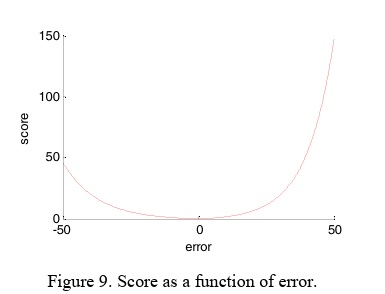

In [ ]:
# Asymmetric Scoring 함수 정의

import numpy as np
import matplotlib.pyplot as plt

def compute_nasa_score(y_true, y_pred):
    """
    NASA C-MAPSS Asymmetric Scoring Function
    - Late Prediction (d > 0): Penalty grows fast (a2 = 10)
    - Early Prediction (d < 0): Penalty grows slower (a1 = 13)
    """
    d = y_pred - y_true
    # 벡터화 연산 (빠른 계산)
    scores = np.where(d < 0, np.exp(-d/13) - 1, np.exp(d/10) - 1)
    return np.sum(scores)

In [ ]:
# [디버깅] 학습 데이터 최종 점검
print(f"학습용 Feature 개수: {len(final_features)}")
print(f"X_train shape: {X_train.shape}")
print(f"y_train (RUL) 0~5개: \n{y_train[:5]}")

# 100으로 클리핑 되었는지 재확인
if y_train.max() > 100:
    print("🚨 경고: RUL 클리핑이 적용되지 않았습니다!")
else:
    print("✅ 확인: RUL이 100으로 잘 제한되었습니다.")

# Feature에 이상한게 섞여있는지 확인
invalid_cols = [c for c in final_features if c in ['unit_number', 'RUL', 'max_cycle']]
if invalid_cols:
    print(f"🚨 경고: 입력 변수에 포함되면 안 되는 컬럼이 있습니다: {invalid_cols}")

## 모델링 (ML 6가지 모델, autogluon, 앙상블)

FD-002는 FD-001보다 데이터양이 많다. svr은 데이터가 많은 경우 시간이 너무 오래 걸려 Nystroem으로 변경("커널 트릭"의 비선형 효과는 유지하면서 속도는 선형 모델급)

In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# 모델 라이브러리
from sklearn.linear_model import Ridge
from sklearn.kernel_approximation import Nystroem
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

# =========================================================
# 0.Custom Objective 정의
# =========================================================

def nasa_custom_obj(y_true, y_pred):
    """
    XGBoost / LightGBM용 Custom Objective Function
    Gradient(1차 미분)와 Hessian(2차 미분)을 반환해야 함
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    d = y_pred - y_true # Error
    
    # Gradient (d < 0: early, d >= 0: late)
    grad = np.where(d < 0, 
                    -1/13 * np.exp(-d/13), 
                    1/10 * np.exp(d/10))
    
    # Hessian
    hess = np.where(d < 0, 
                    1/169 * np.exp(-d/13), 
                    1/100 * np.exp(d/10))
    
    return grad, hess

# =========================================================
# 1. 모델 튜닝 설정 (Custom Objective 적용)
# =========================================================
models = {} 

def get_model_from_trial(trial, model_name):
    
    if model_name == 'Ridge':
        params = {
            'alpha': trial.suggest_float('alpha', 0.1, 200.0, log=True), 
            'random_state': 42
        }
        return Ridge(**params)

    elif model_name == 'Fast SVR':
        # [수정] Nystroem 근사 + Ridge 조합으로 변경 (Fast SVR)
        
        # 1. Hyperparameter 정의
        # gamma: RBF 커널의 폭 (SVR의 gamma와 동일)
        gamma = trial.suggest_float('gamma', 0.001, 1.0, log=True)
        
        # n_components: 근사할 차원 수 (클수록 정확하지만 느려짐. 500~1000 추천)
        n_components = trial.suggest_int('n_components', 300, 1000)
        
        # alpha: 규제 강도 (SVR의 C와 반대 개념. C가 클수록 alpha는 작아야 함)
        # SVR C(0.1 ~ 1000) ≈ Ridge alpha(10 ~ 0.001)
        alpha = trial.suggest_float('alpha', 0.01, 100.0, log=True)
        
        # 2. Pipeline 구성
        # Step 1: Nystroem이 데이터를 고차원으로 뻥튀기 (비선형성 확보)
        # Step 2: Ridge가 선형 회귀로 빠르게 학습 (속도 확보)
        return Pipeline([
            ('feature_map', Nystroem(kernel='rbf', gamma=gamma, n_components=n_components, random_state=42)),
            ('model', Ridge(alpha=alpha))
        ])
    
    elif model_name == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'max_depth': trial.suggest_int('max_depth', 3, 9),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'n_jobs': -1, 
            'random_state': 42,
            'objective': nasa_custom_obj  # [핵심] Custom Objective 적용!
        }
        return XGBRegressor(**params)

    elif model_name == 'LightGBM':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 800),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
            'num_leaves': trial.suggest_int('num_leaves', 20, 100),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
            'verbose': -1, 
            'random_state': 42,
            'objective': nasa_custom_obj  # [핵심] Custom Objective 적용!
        }
        return LGBMRegressor(**params)

    elif model_name == 'RandomForest':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 200),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            'n_jobs': -1, 'random_state': 42
        }
        return RandomForestRegressor(**params)
        

    elif model_name == 'KNN':
        params = {
            'n_neighbors': trial.suggest_int('n_neighbors', 3, 20),
            'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
            'p': trial.suggest_int('p', 1, 2)
        }
        return KNeighborsRegressor(**params)
    
    return None

def objective(trial, model_name):
    model = get_model_from_trial(trial, model_name)
    
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # 3-Fold CV
    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    scores = []
    
    # SVR 등 느린 모델을 위한 샘플링 (기존 로직 유지)
    if model_name == 'SVR' and len(X_train) > 5000:
        sample_idx = np.random.choice(len(X_train), size=5000, replace=False)
        X_tr_tuning = X_train.iloc[sample_idx]
        y_tr_tuning = y_train.iloc[sample_idx]
    else:
        X_tr_tuning = X_train
        y_tr_tuning = y_train

    for train_idx, val_idx in kf.split(X_tr_tuning):
        X_tr = X_tr_tuning.iloc[train_idx]
        X_val = X_tr_tuning.iloc[val_idx]
        y_tr = y_tr_tuning.iloc[train_idx]
        y_val = y_tr_tuning.iloc[val_idx]
        
        pipeline.fit(X_tr, y_tr)
        pred = pipeline.predict(X_val)
        
        # [변경] RMSE 대신 NASA Scoring Function 사용
        score = compute_nasa_score(y_val, pred)
        scores.append(score)
        
    return np.mean(scores) # Fold별 NASA 점수의 평균을 최소화

# =========================================================
# 3. 튜닝 실행 루프
# =========================================================
target_models = ['XGBoost', 'LightGBM', 'RandomForest', 'KNN','Fast SVR', 'Ridge']

print("🚀 [Hyperparameter Tuning] NASA Scoring 기반 최적화 시작...")

for name in target_models:
    print(f"\n🔧 Tuning {name}...", end=" ")
    
    n_trials = 10 if name == 'SVR' else 20
    
    study = optuna.create_study(direction='minimize') # 점수는 낮을수록 좋음
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    
    study.optimize(lambda trial: objective(trial, name), n_trials=n_trials)
    
    print(f"-> Best NASA Score: {study.best_value:,.2f}")
    
    best_model = get_model_from_trial(study.best_trial, name)
    models[name] = best_model

print("\n✨ 모든 모델 튜닝 완료! 이제 모델들은 NASA 점수에 최적화되었습니다.")

＊  FD-001과 달리 safe mergin -3이 검증하는 과정을 다룬다. nasa score 기준으로 검증한다.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# 1. Validation 데이터로 개별 모델 예측 수집
# ---------------------------------------------------------
val_preds_dict = {}
feature_cols = ALL_FEATURES

# Scikit-learn 모델
for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    try:
        pipeline.fit(X_train, y_train)
        val_preds_dict[name] = pipeline.predict(X_val)
    except Exception as e:
        print(f"⚠️ {name} 실패: {e}")

# AutoGluon (있으면 추가)
if 'predictor' in dir() or 'predictor' in globals():
    try:
        val_data_ag = X_val.copy()
        val_data_ag['RUL'] = y_val
        ag_val_pred = predictor.predict(val_data_ag.drop(columns=['RUL']))
        val_preds_dict['AutoGluon'] = ag_val_pred.values
    except:
        pass

# ---------------------------------------------------------
# 2. 앙상블 예측 (단순 평균)
# ---------------------------------------------------------
val_ensemble = np.mean(list(val_preds_dict.values()), axis=0)

# ---------------------------------------------------------
# 3. Safety Margin Grid Search (NASA Score 기준)
# ---------------------------------------------------------
print("🔍 Safety Margin 최적값 탐색 (NASA Score 기준)...")

margin_range = np.arange(-15, 6, 1)  # -15 ~ +5
margin_scores = []

for margin in margin_range:
    adjusted_pred = val_ensemble + margin
    adjusted_pred = np.maximum(adjusted_pred, 0)
    score = compute_nasa_score(y_val.values, adjusted_pred)
    margin_scores.append(score)

best_idx = np.argmin(margin_scores)
best_margin = margin_range[best_idx]
best_score = margin_scores[best_idx]

print(f"\n🏆 Best Safety Margin: {best_margin:+.0f}")
print(f"   NASA Score: {best_score:,.0f}")
print(f"   (Margin=0 대비 {((margin_scores[list(margin_range).index(0)] - best_score) / margin_scores[list(margin_range).index(0)] * 100):.1f}% 개선)")

# 시각화
plt.figure(figsize=(10, 5))
plt.plot(margin_range, margin_scores, 'b-o', markersize=4)
plt.axvline(best_margin, color='red', linestyle='--', label=f'Best: {best_margin:+.0f}')
plt.xlabel('Safety Margin')
plt.ylabel('NASA Score (lower is better)')
plt.title('Safety Margin Optimization (Validation Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

# =========================================================
# 🚀 [Phase 1] 최종 모델 성능 종합 평가 (Safety Margin -7 적용)
# =========================================================
print("\n🚀 [Phase 1] 최종 모델 성능 비교 시작 (NASA Score + 5대 지표)...")
print("*" * 110)
print(f"{'Model':<12} | {'NASA Score':<12} | {'RMSE':<10} | {'RMSLE':<10} | {'MAE':<10} | {'R2':<10}")
print("-" * 110)

# 1. NASA Asymmetric Score 함수 정의 (안전을 위해 여기서 재정의)
# (Late Prediction에 가중치를 두어 벌점을 매기는 공식)
def compute_nasa_score(y_true, y_pred):
    d = y_pred - y_true
    # d < 0 (Early Prediction): 페널티 작음 (exp(-d/13))
    # d > 0 (Late Prediction): 페널티 큼 (exp(d/10)) -> 고장났는데 안났다고 하면 큰일남!
    scores = np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1)
    return np.sum(scores)

results_list = []

# models 딕셔너리에 있는 모든 모델(Ridge, SVR, XGB 등)을 순회하며 평가
for name, model in models.items():
    # (1) 파이프라인 생성: 결측치처리 -> 스케일링 -> 모델
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # (2) 전체 데이터로 재학습 (Optuna로 찾은 최적 파라미터 적용됨)
    pipeline.fit(X_train, y_train)
    
    # (3) 테스트 데이터(X_test) 예측
    # X_test는 각 엔진의 '마지막 시점' 데이터여야 합니다.
    y_pred = pipeline.predict(X_test)
    
    # 🔥 [핵심 전략] Safety Margin 적용 (Technique C)
    # 예측값에서 7을 빼서 "약간 일찍 고장난다고" 예측하게 만듦 -> Late Prediction 방지
    y_pred = y_pred - 7
    
    # (4) 음수 보정 (물리적으로 불가능한 값 제거 및 RMSLE 에러 방지)
    y_pred = np.maximum(y_pred, 0)
   

    ### y_test도 클리핑 추가 나중에 삭제 가능
    y_test_clipped = np.minimum(y_test, 100) # best_limit이 100인 경우

    # (5) 모든 평가지표 계산
    nasa_score = compute_nasa_score(y_test, y_pred)  # 낮을수록 좋음
    rmse = np.sqrt(mean_squared_error(y_test, y_pred)) # 낮을수록 좋음
    mae = mean_absolute_error(y_test, y_pred)          # 낮을수록 좋음
    r2 = r2_score(y_test, y_pred)                      # 1에 가까울수록 좋음 (높을수록 좋음)
    
    # RMSLE (로그 오차, 에러 방지 처리 포함)
    try:
        rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
    except:
        rmsle = 0.0 # 만약 계산 불가능하면 0 처리

    # 결과 리스트에 저장
    results_list.append({
        'Model': name,
        'NASA Score': nasa_score,
        'RMSE': rmse,
        'RMSLE': rmsle,
        'MAE': mae,
        'R2': r2
    })
    
    # 한 줄씩 출력 (진행 상황 확인용)
    print(f"{name:<12} | {nasa_score:<12.2f} | {rmse:<10.4f} | {rmsle:<10.4f} | {mae:<10.4f} | {r2:<10.4f}")

print("*" * 110)

# 2. 결과 요약 및 우승 모델 선정
results_df = pd.DataFrame(results_list).set_index('Model')

# NASA Score가 가장 낮은(좋은) 모델 선정
best_model_name = results_df['NASA Score'].idxmin()
best_score = results_df.loc[best_model_name, 'NASA Score']

print(f"\n🏆 Best Model (by NASA Score): {best_model_name}")
print(f"💎 Score: {best_score:.2f} (낮을수록 좋으며, 500점 이하면 매우 우수함)")

print("\n📊 [Score 기준 정렬된 전체 결과표]")
print(results_df.sort_values('NASA Score'))

# (선택 사항) CSV로 결과 저장
# results_df.to_csv("Phase1_Model_Evaluation.csv")

In [ ]:
# =========================================================
# 📈 [Visualization] 모델 성능 비교 시각화
# =========================================================

# 그래프 스타일 설정
sns.set(style="whitegrid")

# 2x2 서브플롯 생성
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. RMSLE 비교 (낮을수록 좋음)
# 가장 낮은(좋은) 값은 초록색, 나머지는 파란색
colors_rmsle = ['green' if x == results_df['RMSLE'].min() else 'steelblue' for x in results_df['RMSLE']]
axes[0, 0].barh(results_df.index, results_df['RMSLE'], color=colors_rmsle)
axes[0, 0].set_title('RMSLE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('RMSLE')

# 2. RMSE 비교 (낮을수록 좋음)
colors_rmse = ['green' if x == results_df['RMSE'].min() else 'steelblue' for x in results_df['RMSE']]
axes[0, 1].barh(results_df.index, results_df['RMSE'], color=colors_rmse)
axes[0, 1].set_title('RMSE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('RMSE')

# 3. MAE 비교 (낮을수록 좋음)
colors_mae = ['green' if x == results_df['MAE'].min() else 'steelblue' for x in results_df['MAE']]
axes[1, 0].barh(results_df.index, results_df['MAE'], color=colors_mae)
axes[1, 0].set_title('MAE Comparison (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('MAE')

# 4. R² Score 비교 (높을수록 좋음)
# 가장 높은(좋은) 값은 초록색
colors_r2 = ['green' if x == results_df['R2'].max() else 'steelblue' for x in results_df['R2']]
axes[1, 1].barh(results_df.index, results_df['R2'], color=colors_r2)
axes[1, 1].set_title('R² Score Comparison (Higher is Better)', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('R² Score')
axes[1, 1].set_xlim(0, 1) # R2는 보통 0~1 사이

plt.tight_layout()
plt.show()

In [ ]:
# ---------------------------------------------------------
# [수정] Safety Margin이 적용된 v2 시각화 함수
# ---------------------------------------------------------
def plot_engine_trajectory_v2(model_name, pipeline, test_full_df, unit_id, feature_cols):
    engine_data = test_full_df[test_full_df['unit_number'] == unit_id].copy()
    
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    # [중요] 학습에 사용된 피처 순서 그대로 추출
    X_engine = engine_data[feature_cols]
    y_true = engine_data['RUL']
    
    # 예측
    y_pred = pipeline.predict(X_engine)
    
    # 🔧 [Technique C] Safety Margin 적용 (-7)
    # 시각화에서도 점수판과 동일하게 7점 낮춰서 그립니다.
    y_pred = y_pred - 7
    
    y_pred = np.maximum(y_pred, 0) 

    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    # 범례에도 마진 적용 사실 명시
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-', label=f'Pred by {model_name} (Margin -3)', alpha=0.8)
    
    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name}")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# ---------------------------------------------------------
# [수정] Safety Margin이 적용된 v2 시각화 함수
# ---------------------------------------------------------
def plot_engine_trajectory_v2(model_name, pipeline, test_full_df, unit_id, feature_cols):
    engine_data = test_full_df[test_full_df['unit_number'] == unit_id].copy()
    
    if len(engine_data) == 0:
        print(f"⚠️ Unit {unit_id} 데이터가 없습니다.")
        return

    # [중요] 학습에 사용된 피처 순서 그대로 추출
    X_engine = engine_data[feature_cols]
    y_true = engine_data['RUL']
    
    # 예측
    y_pred = pipeline.predict(X_engine)
    
    # 🔧 [Technique C] Safety Margin 적용 (-3)
    # 시각화에서도 점수판과 동일하게 3점 낮춰서 그립니다.
    y_pred = y_pred - 7
    
    y_pred = np.maximum(y_pred, 0) 

    plt.figure(figsize=(10, 4))
    plt.plot(engine_data['time_in_cycles'], y_true, 'r--', label='True RUL', linewidth=2)
    # 범례에도 마진 적용 사실 명시
    plt.plot(engine_data['time_in_cycles'], y_pred, 'b-', label=f'Pred by {model_name} (Margin -3)', alpha=0.8)
    
    plt.title(f"Unit #{unit_id} RUL Trajectory - {model_name}")
    plt.xlabel("Time (Cycles)")
    plt.ylabel("RUL")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 실행 ---
target_unit = 24
all_features = X_train.columns.tolist() 

print(f"🎨 [Visualization] Unit {target_unit} 예측 패턴 확인 (Margin -3 적용됨)")

for name, model in models.items():
    # 파이프라인 구성 (전처리 + 모델)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # [안전장치] 재학습 (Safety Margin의 효과를 정확히 보기 위해)
    pipeline.fit(X_train, y_train)
    
    # 시각화 함수 호출
    plot_engine_trajectory_v2(name, pipeline, test_working, target_unit, all_features)

## Autogluon Best-quality 모델 
pc의 성능을 극대화하기 위해 GPU와 cpu의 p-코어 만을 사용. e-코어는 병목

In [ ]:
from autogluon.tabular import TabularPredictor
import pandas as pd
import torch  # GPU 확인용

# =========================================================
# 🚀 [Phase 2] AutoGluon: GPU + P-Core 최적화 & Best Quality
# =========================================================

print(f"🔥 GPU 사용 가능 여부: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🔥 감지된 GPU: {torch.cuda.get_device_name(0)}")

# ---------------------------------------------------------
# 1. AutoGluon용 데이터셋 준비 (DataFrame 형태)
# ---------------------------------------------------------
# AutoGluon은 스케일링 되지 않은 '원본 데이터'를 선호합니다. (Phase 1의 Pipeline과 다름)

# (1) 학습 데이터 (Train)
train_data_ag = X_train.copy()
train_data_ag['RUL'] = y_train

# (2) 검증 데이터 (Validation) - use_bag_holdout을 위해 필수
val_data_ag = X_val.copy()
val_data_ag['RUL'] = y_val

# (3) 테스트 데이터 (Test) - 최종 평가용
test_data_ag = X_test.copy()
test_data_ag['RUL'] = y_test

print(f"학습 데이터: {train_data_ag.shape}")
print(f"검증 데이터: {val_data_ag.shape}")

# ---------------------------------------------------------
# 2. AutoGluon 학습 (최적화 옵션 적용)
# ---------------------------------------------------------

# 예측기 초기화
predictor = TabularPredictor(
    label='RUL', 
    eval_metric='root_mean_squared_error', # 평가는 RMSE 기준
    problem_type='regression',             # 회귀 문제 명시
    path='ag_models_best_quality'          # 모델 저장 경로
)

# 학습 시작 (사용자 요청 하드웨어 최적화 반영)
predictor.fit(
    train_data=train_data_ag,
    tuning_data=val_data_ag,       # 별도의 검증 데이터 지정
    
    # [핵심 전략] 검증 데이터(tuning_data)를 섞지 않고 별도로 유지하며 배깅 수행
    # (일반적인 K-Fold보다 검증 신뢰도가 높고, Overfitting을 강력하게 방지함)
    use_bag_holdout=True,    
    
    presets='best_quality',        # 최고 성능 모드 (Bagging + Stacking 자동 적용)
    time_limit=600,                # 10분 (GPU 가속 덕분에 충분함)
    
    # [하드웨어 최적화]
    num_gpus=1,                    # RTX 4070 Super 활성화 (CatBoost, NeuralNet 가속)
    num_cpus=16,                   # i9-13900K P-코어 개수에 맞춰 스레드 제한 (E-코어 간섭 방지)
    
    verbosity=2
)

# ---------------------------------------------------------
# 3. 결과 평가 및 리더보드 확인
# ---------------------------------------------------------

print("\n📊 [Phase 2] AutoGluon 리더보드 (검증 데이터 기준)")
# 검증 데이터(val_data_ag)에 대한 성능 순위 확인
lb = predictor.leaderboard(val_data_ag, silent=True)
print(lb[['model', 'score_test', 'score_val', 'pred_time_test']].head(10))

print("\n🏆 [Phase 2] 최종 테스트(Test) 데이터 평가")
# X_test에 대한 최종 성능 측정
perf = predictor.evaluate(test_data_ag)
print(f"실전 테스트 RMSE: {perf['root_mean_squared_error']:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# [Phase 2] AutoGluon 시각화 (Safety Margin -7 적용)
# ---------------------------------------------------------
print(f"🎨 [Phase 2] AutoGluon의 Unit {target_unit} 예측 패턴 시각화")

# 1. 해당 유닛 데이터 추출
# (test_working은 위에서 만든 '시각화용 데이터'입니다)
engine_data = test_working[test_working['unit_number'] == target_unit].copy()

# 2. AutoGluon 예측
# AutoGluon은 DataFrame을 통째로 넣으면 학습 때 쓴 컬럼을 알아서 찾아 씁니다.
y_pred_ag = predictor.predict(engine_data)

# 🛠️ [Technique C] Safety Margin 적용 (-7)
# AutoGluon 예측값에도 똑같이 마진을 적용해야 점수판과 일치합니다.
y_pred_ag = y_pred_ag - 7
y_pred_ag = np.maximum(y_pred_ag, 0) # 음수 보정

# 3. 그래프 그리기
plt.figure(figsize=(10, 4))
plt.plot(engine_data['time_in_cycles'], engine_data['RUL'], 'r--', label='True RUL', linewidth=2)
plt.plot(engine_data['time_in_cycles'], y_pred_ag, 'g-', label='Pred by AutoGluon (Margin -3)', alpha=0.8)

plt.title(f"Unit #{target_unit} RUL Trajectory - AutoGluon")
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### k-fold cross validation

In [ ]:
from scipy.optimize import minimize
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import mean_squared_error

# =========================================================
# 1. 데이터 및 변수 준비
# =========================================================
print("\n🚀 [Phase 3] K-Fold 기반 앙상블 가중치 최적화 시작...")

# 전체 데이터 정의 (Train 전체)
full_X = train_smoothed[ALL_FEATURES]
full_y = train_smoothed['RUL']

# K-Fold 설정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 모델별 예측값을 저장할 리스트 (Train용, Test용)
# Train용은 가중치 찾는 용도, Test용은 최종 제출 용도
oof_preds_list = []   # Out-Of-Fold Predictions (학습 데이터 전체에 대한 예측)
test_preds_list = []  # X_test에 대한 예측

# 튜닝된 모델 이름 목록 (Phase 1의 models 딕셔너리 사용)
# AutoGluon은 별도 처리하거나 제외 (여기서는 sklearn 호환 모델만 사용)
target_model_names = list(models.keys()) 

# =========================================================
# 2. 각 모델별 K-Fold 예측 수행 (데이터 모으기)
# =========================================================
for name in target_model_names:
    model = models[name]
    
    # 파이프라인 생성
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    print(f"🔄 {name}: K-Fold 예측 데이터 생성 중...", end=" ")
    
    # 1) Train 데이터에 대한 OOF 예측 (가중치 학습용)
    # cross_val_predict는 교차 검증을 통해 전체 데이터에 대한 예측값을 생성합니다.
    oof_pred = cross_val_predict(pipeline, full_X, full_y, cv=kf, n_jobs=-1)
    # 음수 보정
    oof_pred = np.maximum(oof_pred, 0)
    oof_preds_list.append(oof_pred)
    
    # 2) Test 데이터에 대한 예측 (최종 평가용)
    # 전체 데이터로 한 번 더 학습 후 Test 예측
    pipeline.fit(full_X, full_y)
    test_pred = pipeline.predict(X_test)
    test_pred = np.maximum(test_pred, 0)
    test_preds_list.append(test_pred)
    
    rmse = np.sqrt(mean_squared_error(full_y, oof_pred))
    print(f"완료 (RMSE: {rmse:.4f})")

# =========================================================
# 3. 가중치 최적화 (scipy.minimize)
# =========================================================
print("\n⚖️ 최적의 앙상블 가중치 탐색 중...")

def ensemble_objective(weights, predictions, y_true):
    # 가중치 적용 예측
    final_pred = np.zeros_like(predictions[0])
    for w, pred in zip(weights, predictions):
        final_pred += w * pred
    
    # RMSE 최소화 목표
    return np.sqrt(mean_squared_error(y_true, final_pred))

# 초기 가중치 (1/N)
n_models = len(oof_preds_list)
init_weights = [1/n_models] * n_models

# 제약조건 (합 = 1, 0 <= 가중치 <= 1)
constraints = ({'type': 'eq', 'fun': lambda w: 1 - sum(w)})
bounds = [(0, 1)] * n_models

# 최적화 실행
res = minimize(ensemble_objective, 
               init_weights, 
               args=(oof_preds_list, full_y), 
               method='SLSQP', 
               bounds=bounds, 
               constraints=constraints)

best_weights = res.x

print("-" * 50)
print("🏆 최적 가중치 발견!")
for name, w in zip(target_model_names, best_weights):
    print(f"   • {name}: {w:.4f}")
print("-" * 50)

# =========================================================
# 4. 최종 앙상블 결과 평가 (Weighted Ensemble)
# =========================================================

# Test 데이터에 가중치 적용
final_ensemble_pred = np.zeros_like(test_preds_list[0])
for w, pred in zip(best_weights, test_preds_list):
    final_ensemble_pred += w * pred

# 성능 평가
y_test_vals = y_test.values
final_rmse = np.sqrt(mean_squared_error(y_test_vals, final_ensemble_pred))
final_rmsle = np.sqrt(mean_squared_log_error(y_test_vals, final_ensemble_pred))
final_r2 = r2_score(y_test_vals, final_ensemble_pred)
final_nasa = compute_nasa_score(y_test_vals, final_ensemble_pred)

print(f"\n🚀 [Phase 3 Final] 가중치 앙상블 결과 (Test Set)")
print(f"   • RMSE : {final_rmse:.4f}")
print(f"   • RMSLE: {final_rmsle:.4f}")
print(f"   • R2   : {final_r2:.4f}")
print(f"   • NASA Score: {final_nasa:,.2f}")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# ---------------------------------------------------------
# [Phase 3] 최종 앙상블 시각화 (Safety Margin -7 적용)
# ---------------------------------------------------------
print(f"🎨 [Phase 3] 최종 앙상블(Weighted Ensemble) Unit {target_unit} 예측")

# 1. 개별 모델 예측값 수집
preds_dict = {}
# 학습에 사용된 컬럼 리스트 (시각화용 데이터에서도 이 컬럼만 뽑아서 씀)
feature_cols = X_train.columns.tolist() 

# (1) Scikit-learn Pipeline 모델 예측 (Ridge, SVR, XGB 등)
for name, model in models.items():
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    # [안전장치] 재학습 (Safety Margin 효과를 정확히 보기 위해)
    try:
        pipeline.fit(X_train, y_train) 
        
        # 해당 유닛 데이터 추출
        engine_data = test_working[test_working['unit_number'] == target_unit]
        X_engine = engine_data[feature_cols]
        
        preds_dict[name] = pipeline.predict(X_engine)
    except Exception as e:
        print(f"⚠️ {name} 예측 실패: {e}")

# (2) AutoGluon 예측
try:
    engine_data = test_working[test_working['unit_number'] == target_unit]
    preds_dict['AutoGluon'] = predictor.predict(engine_data)
except Exception as e:
    print(f"⚠️ AutoGluon 예측 실패: {e}")

# 2. 가중치 적용 및 앙상블 (에러 수정 파트)
# ---------------------------------------------------------
# 1) best_weights가 없으면 생성
if 'best_weights' not in locals():
    print("⚠️ best_weights가 없어 평균(Equal Weight)으로 계산합니다.")
    best_weights = np.ones(len(preds_dict)) / len(preds_dict) # 배열로 초기화

# 2) 모델 순서 정의 (학습할 때와 동일한 순서라고 가정)
# 순서: models에 있는 것들 + AutoGluon
model_order = list(models.keys())
if 'AutoGluon' in preds_dict:
    model_order.append('AutoGluon')

# 3) best_weights가 배열(numpy array)인 경우 -> 딕셔너리로 변환
if not isinstance(best_weights, dict):
    # 배열의 길이와 모델 개수가 다르면 (혹시 모를 상황 대비)
    if len(best_weights) != len(model_order):
        print(f"⚠️ 가중치 개수({len(best_weights)})와 모델 개수({len(model_order)})가 달라 평균을 사용합니다.")
        best_weights_dict = {m: 1.0/len(model_order) for m in model_order}
    else:
        # 배열을 딕셔너리로 매핑 ({'Ridge': 0.1, ...})
        best_weights_dict = dict(zip(model_order, best_weights))
else:
    # 이미 딕셔너리라면 그대로 사용
    best_weights_dict = best_weights

# ---------------------------------------------------------

final_pred = np.zeros(len(engine_data))
used_models = []

for model_name, weight in best_weights_dict.items():
    if model_name in preds_dict:
        # 가중치가 0.01보다 큰 모델만 라벨에 표시 (너무 작은건 생략)
        if weight > 0.01:
            used_models.append(f"{model_name}({weight:.2f})")
            
        final_pred += weight * preds_dict[model_name]

# 🛠️ [Technique C] Safety Margin 적용 (-7)
final_pred = final_pred - 7
final_pred = np.maximum(final_pred, 0) # 음수 보정

# 3. 그래프 그리기
plt.figure(figsize=(12, 5))
plt.plot(engine_data['time_in_cycles'], engine_data['RUL'], 'r--', label='True RUL', linewidth=2)
# 범례에 Margin 적용 사실 명시
plt.plot(engine_data['time_in_cycles'], final_pred, 'g-', label='Ensemble Prediction (Margin -3)', linewidth=2)

plt.title(f"Final Ensemble Result (Unit #{target_unit})\nModels: {', '.join(used_models)}")
plt.xlabel("Time (Cycles)")
plt.ylabel("RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 결과 비교 및 분석

In [ ]:
print("📊 results_df 확인:")
print(results_df)
print("\n" + "="*50)
print("📊 results_df 통계:")
print(results_df.describe())
print("\n" + "="*50)
print("극단값 확인 (RMSLE > 1):")
print(results_df[results_df['RMSLE'] > 1])

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_log_error, r2_score, mean_squared_error, mean_absolute_error

# 1. 데이터 준비 
final_df = results_df.copy()

# 2. AutoGluon 추가
ag_pred = predictor.predict(test_data_ag)
ag_pred_clipped = np.maximum(ag_pred, 1e-6)
y_test_clipped = np.maximum(y_test.values, 1e-6)

ag_rmse = np.sqrt(mean_squared_error(y_test, ag_pred))
ag_rmsle = np.sqrt(mean_squared_log_error(y_test_clipped, ag_pred_clipped))
ag_mae = mean_absolute_error(y_test, ag_pred)
ag_r2 = r2_score(y_test, ag_pred)

ag_row = pd.DataFrame([{
    'RMSE': ag_rmse, 
    'RMSLE': ag_rmsle, 
    'MAE': ag_mae, 
    'R2': ag_r2
}], index=['AutoGluon'])

final_df = pd.concat([final_df, ag_row])

print("📊 시각화 데이터 (LinearReg 제외):")
print(final_df)

# 3. 시각화
final_df = final_df.sort_values('RMSLE', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 색상 설정
colors = ['darkgreen' if 'AutoGluon' in str(idx) else 'steelblue' for idx in final_df.index]

# RMSLE 그래프
axes[0].barh(final_df.index, final_df['RMSLE'], color=colors, edgecolor='black')
axes[0].set_xlabel('RMSLE (Lower is Better)', fontweight='bold')
axes[0].set_title('Model Comparison - RMSLE', fontweight='bold')
axes[0].axvline(x=final_df['RMSLE'].min(), color='red', linestyle='--', alpha=0.6)

for i, (idx, val) in enumerate(final_df['RMSLE'].items()):
    axes[0].text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold')

# R2 그래프
axes[1].barh(final_df.index, final_df['R2'], color=colors, edgecolor='black')
axes[1].set_xlabel('R² Score (Higher is Better)', fontweight='bold')
axes[1].set_title('Model Comparison - R² Score', fontweight='bold')
axes[1].set_xlim(0, 1.0)
axes[1].axvline(x=final_df['R2'].max(), color='red', linestyle='--', alpha=0.6)

for i, (idx, val) in enumerate(final_df['R2'].items()):
    axes[1].text(val + 0.01, i, f'{val:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# 4. 결론
best_model = final_df['RMSLE'].idxmin()
print(f"\n🏆 최종 승자: {best_model}")
print(f"   RMSLE: {final_df.loc[best_model, 'RMSLE']:.4f}")
print(f"   R2: {final_df.loc[best_model, 'R2']:.4f}")

print("\n📋 전체 순위 (RMSLE 기준):")
print(final_df.sort_values('RMSLE')[['RMSLE', 'R2']])

In [ ]:
import math

# =========================================================
# 1. 모든 모델의 예측값 확보 (All Predictions)
# =========================================================

all_results = {}
ensemble_preds = [] # 앙상블을 만들기 위해 예측값들을 모아둘 리스트

print("🚀 모든 모델에 대해 채점을 시작합니다...")

# (1) Phase 1의 6개 모델 예측
for name, model in models.items():
    # 파이프라인 재구성 (Imputer -> Scaler -> Model)
    # (주의: 이미 학습된 모델 객체를 사용하므로 fit은 생략 가능하거나, 필요시 재학습)
    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    pipeline.fit(X_train, y_train) # 안전하게 재학습 (시간이 걸리면 생략 가능)
    
    pred = pipeline.predict(X_test)
    pred = np.maximum(pred, 0) # 음수 보정
    
    all_results[name] = pred
    ensemble_preds.append(pred) # 앙상블용으로 저장

# (2) Phase 2 AutoGluon 예측
ag_pred = predictor.predict(test_data_ag)
ag_pred = np.maximum(ag_pred, 0)
all_results['AutoGluon'] = ag_pred.values # Series -> Array 변환
ensemble_preds.append(ag_pred.values) # 앙상블에 AutoGluon도 포함 (성능 향상 비결!)

# (3) [New] 평균 앙상블 (Simple Averaging Ensemble) 생성
# 위 7개 모델의 예측값을 다 더해서 평균을 냅니다.
avg_ensemble_pred = np.mean(ensemble_preds, axis=0)
all_results['Ensemble (Avg)'] = avg_ensemble_pred

print(f"✅ 총 {len(all_results)}개 모델 예측 완료!")


# =========================================================
# 2. Asymmetric Score 계산 및 시각화 (Dynamic Layout)
# =========================================================

# 그래프 배치 계산 (모델 개수에 맞춰 자동 줄바꿈)
n_models = len(all_results)
n_cols = 4 # 한 줄에 4개씩 그리기
n_rows = math.ceil(n_models / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten() # 2차원 배열을 1차원으로 펴서 쓰기 편하게 만듦

final_scores = {}
y_true = y_test.values 

# 반복문으로 그리기
for i, (name, y_pred) in enumerate(all_results.items()):
    ax = axes[i]
    
    # 1. 스코어 계산
    score = compute_nasa_score(y_true, y_pred)
    final_scores[name] = score
    
    # 2. 산점도 그리기
    diff = y_pred - y_true
    max_val = max(y_true.max(), y_pred.max())
    
    # 색상: Late Prediction(빨강) vs Early Prediction(파랑)
    sc = ax.scatter(y_true, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect')
    
    # 위험 구역(Late Prediction) 표시
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    # 꾸미기
    ax.set_title(f"{name}\nScore: {score:,.0f}", fontsize=12, fontweight='bold')
    ax.set_xlabel("True RUL")
    ax.set_ylabel("Predicted")
    ax.grid(True, alpha=0.3)

# 남는 빈 그래프 공간 지우기
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# =========================================================
# 🏆 최종 순위표 출력
# =========================================================
print("\n" + "="*50)
print(f"📊 NASA Asymmetric Scoring 최종 순위 (Total {n_models} Models)")
print("="*50)

# 점수가 낮은 순서대로 정렬 (낮을수록 좋음)
sorted_scores = sorted(final_scores.items(), key=lambda x: x[1])

for rank, (m, s) in enumerate(sorted_scores, 1):
    prefix = "🏆" if rank == 1 else f"{rank}위"
    print(f"{prefix}: {m:<20} | Score: {s:,.2f}")

In [ ]:
import math
import matplotlib.pyplot as plt
import numpy as np

# =========================================================
# 📈 모든 모델 Asymmetric Score 계산 및 그래프 그리기
# =========================================================

# 1. 그래프 레이아웃 설정 (자동 계산)
n_models = len(all_results)
n_cols = 4  # 한 줄에 4개씩 그리기
n_rows = math.ceil(n_models / n_cols) # 모델 수에 맞춰 행 개수 자동 조절

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6 * n_rows))
axes = axes.flatten() # 1차원 배열로 펼침 (인덱싱 편의)

final_scores = {}
y_true = y_test.values 

# 2. 모든 모델 반복문 실행
for i, (name, y_pred) in enumerate(all_results.items()):
    ax = axes[i]
    
    # (1) 스코어 계산
    score = compute_nasa_score(y_true, y_pred)
    final_scores[name] = score
    
    # (2) 오차(Diff) 계산
    diff = y_pred - y_true
    
    # (3) 산점도 그리기 (True vs Pred)
    # 색상: 오차가 클수록(Late Prediction) 빨간색, 작을수록 파란색
    sc = ax.scatter(y_true, y_pred, c=diff, cmap='coolwarm', alpha=0.6, edgecolors='k')
    
    # 기준선 (Perfect Prediction)
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([0, max_val], [0, max_val], 'r--', label='Perfect Line', linewidth=2)
    
    # (4) 꾸미기
    ax.set_title(f"{name}\nNASA Score: {score:,.0f}", fontsize=14, fontweight='bold')
    ax.set_xlabel("True RUL", fontsize=12)
    ax.set_ylabel("Predicted RUL", fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # (5) Asymmetric 영역 표시 (위험 구간 강조)
    # 그래프 상단(예측 > 실제)이 위험 구역
    ax.fill_between([0, max_val], [0, max_val], [max_val, max_val], color='red', alpha=0.05)
    
    # 첫 번째 그래프에만 텍스트 설명 추가 (지저분함 방지)
    if i == 0:
        ax.text(10, max_val-20, "Late Pred (High Penalty)", color='red', fontsize=11, fontweight='bold')
        ax.legend(loc='upper left')

# 3. 남는 빈 그래프 공간 지우기 (모델 개수가 4의 배수가 아닐 때)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 4. 전체 레이아웃 조정 및 컬러바 추가
plt.tight_layout()
# 모든 서브플롯에 대해 하나의 컬러바 공유
cb = fig.colorbar(sc, ax=axes.ravel().tolist(), pad=0.02)
cb.set_label('Prediction Error (Pred - True)', fontsize=12)
plt.show()

# =========================================================
# 🏆 최종 승자 발표 (전체 모델 대상)
# =========================================================
best_model_name = min(final_scores, key=final_scores.get) # 점수가 낮을수록 좋음
best_score = final_scores[best_model_name]

print("\n" + "="*50)
print(f"🏆 Asymmetric Scoring 최종 우승 모델: {best_model_name}")
print(f"💎 Score: {best_score:,.2f} (낮을수록 좋음)")
print("="*50)

print("\n📊 [전체 모델 순위표]")
# 점수 낮은 순 정렬
sorted_scores = sorted(final_scores.items(), key=lambda x: x[1])
for rank, (m, s) in enumerate(sorted_scores, 1):
    medal = ""
    if rank == 1: medal = "🥇"
    elif rank == 2: medal = "🥈"
    elif rank == 3: medal = "🥉"
    
    print(f"{rank}위 {medal}: {m:<25} | Score: {s:,.2f}")